In [21]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent


In [22]:
from src.utils.grid import build_xyz

N = 151
L = 20
alpha = 1.0

dx = L / N
eps = dx / 2
xyz = build_xyz(N, L)
R = np.sqrt(xyz[0]**2 + xyz[1]**2 + xyz[2]**2)

rho_grid = np.exp(-alpha * R**2)

print(f"rho max/min = {rho_grid.max():.4f} / {rho_grid.min():.4f}")

rho max/min = 1.0000 / 0.0000


## 指数関数による展開近似

In [23]:
from src.approximation.exp_sum.grid import LogUniformGrid
from src.approximation.exp_sum.models import ExponentialSum
from src.utils.cache import exp_sum_label as make_exp_sum_label

# ---- scripts/run_exp_sum_fitting.py が保存した .npy を読み込む ----
# notebook 上では重い VARPRO 計算を行わない。計算が必要な場合は、
# Slurm などで `python scripts/run_exp_sum_fitting.py --compute` を実行する。
ranks = list(range(1, 31))
nonneg = True
max_iter = 200000
n_points = 2000
r_min = 1e-2
r_max = np.sqrt(3) * L

exp_sum_label = make_exp_sum_label(
    L=L,
    ranks=ranks,
    nonneg=nonneg,
    max_iter=max_iter,
    n_points=n_points,
    r_min=r_min,
    r_max=r_max,
)

exp_sum_dir = PROJECT_ROOT / "data" / "npy" / "exp_sum" / exp_sum_label
if not exp_sum_dir.exists():
    raise FileNotFoundError(
        f"exp-sum の .npy ディレクトリが見つかりません: {exp_sum_dir}\n"
        "先に計算用 PC / Slurm で "
        "`python scripts/run_exp_sum_fitting.py --compute` を実行してください。"
    )

eval_grid = LogUniformGrid(r_min=r_min, r_max=r_max, n_points=n_points)
r_eval = eval_grid.points
f_eval = 1.0 / r_eval

fits = {}
for r in ranks:
    weights_path = exp_sum_dir / f"R{r:02d}_weights.npy"
    alphas_path = exp_sum_dir / f"R{r:02d}_alphas.npy"
    if not weights_path.exists() or not alphas_path.exists():
        raise FileNotFoundError(
            f"R={r} の exp-sum .npy が見つかりません: {exp_sum_dir}"
        )

    fit = ExponentialSum(
        weights=np.load(weights_path),
        alphas=np.load(alphas_path),
    )
    rel_err = np.abs((fit.evaluate(r_eval) - f_eval) / f_eval)
    fit.l2_error = float(np.sqrt(np.mean(rel_err**2)))
    fit.linf_error = float(np.max(rel_err))
    fits[r] = fit

print(f"Loaded exp-sum .npy -> {exp_sum_dir}")
print(f"{'R':>4}  {'L2 rel err':>14}  {'L∞ rel err':>14}")
print("-" * 38)
for r in sorted(fits):
    print(f"{r:>4}  {fits[r].l2_error:>14.3e}  {fits[r].linf_error:>14.3e}")


Loaded exp-sum .npy -> /home/ikuta/region_PJ/data/npy/exp_sum/L20_rmin1e-02_rmax34.641_n2000_nonneg1_iter200000_R01-30_count30
   R      L2 rel err      L∞ rel err
--------------------------------------
   1       8.887e-01       1.000e+00
   2       8.046e-01       1.000e+00
   3       7.297e-01       1.000e+00
   4       6.586e-01       1.000e+00
   5       5.881e-01       1.000e+00
   6       5.156e-01       1.000e+00
   7       4.381e-01       1.000e+00
   8       3.505e-01       1.000e+00
   9       2.413e-01       9.921e-01
  10       1.306e-01       7.880e-01
  11       7.156e-02       5.135e-01
  12       4.059e-02       3.215e-01
  13       2.328e-02       1.986e-01
  14       1.336e-02       1.216e-01
  15       7.650e-03       7.388e-02
  16       4.377e-03       4.458e-02
  17       2.773e-03       1.997e-02
  18       1.774e-03       1.341e-02
  19       8.919e-04       8.437e-03
  20       5.143e-04       4.242e-03
  21       2.815e-04       1.943e-03
  22       2.645e-04

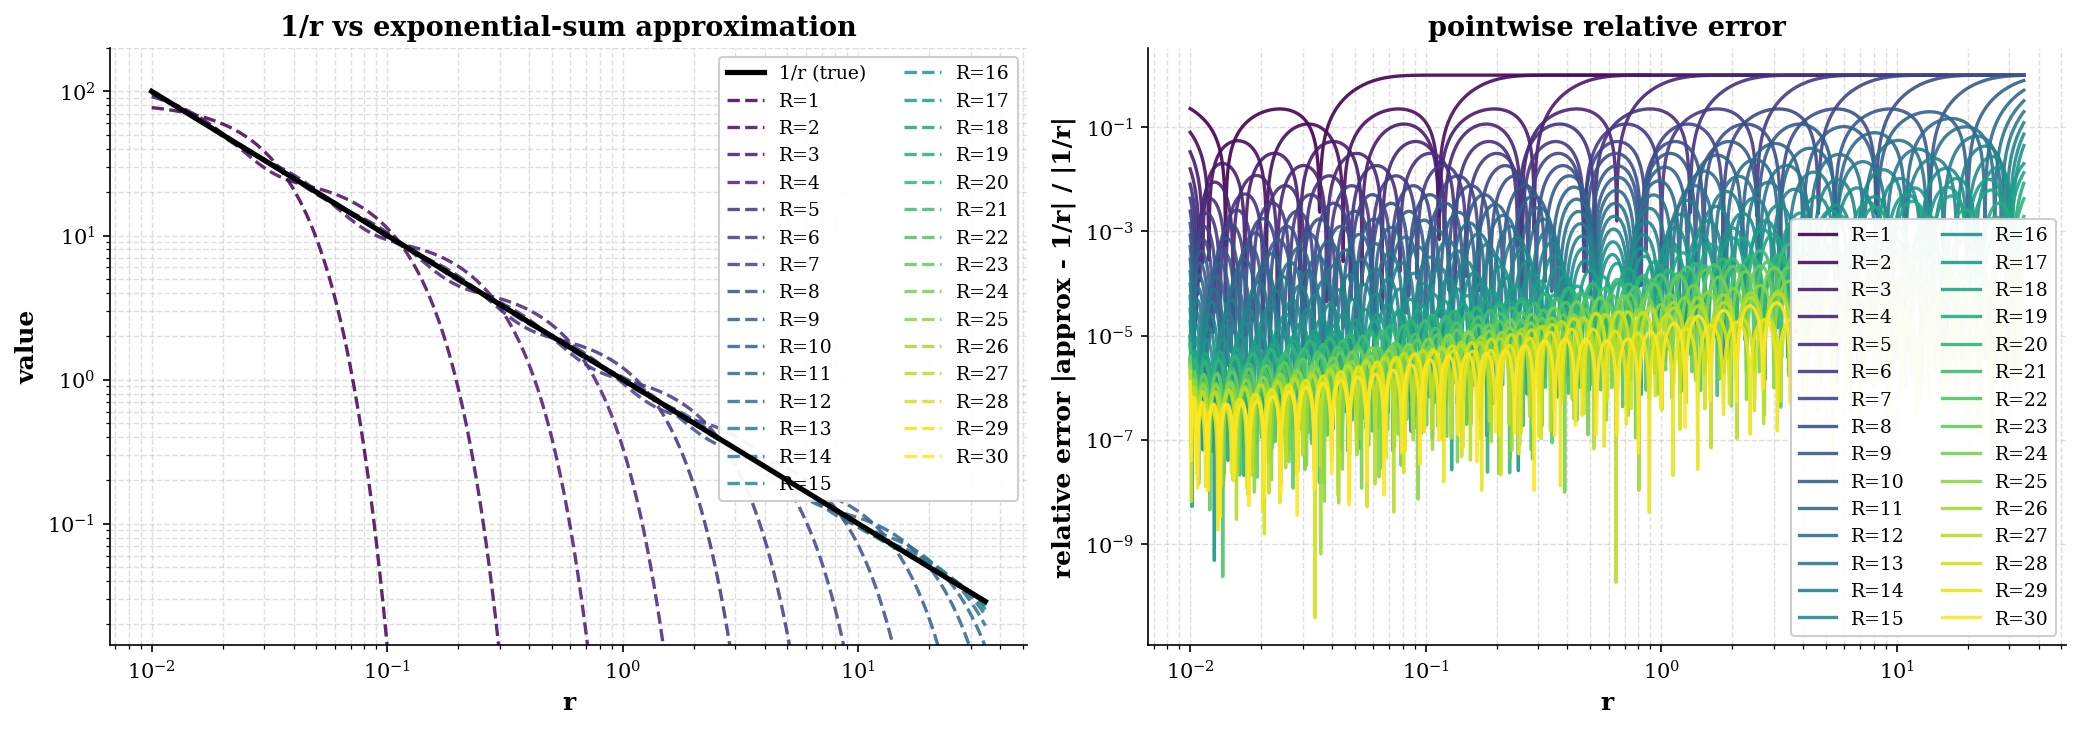

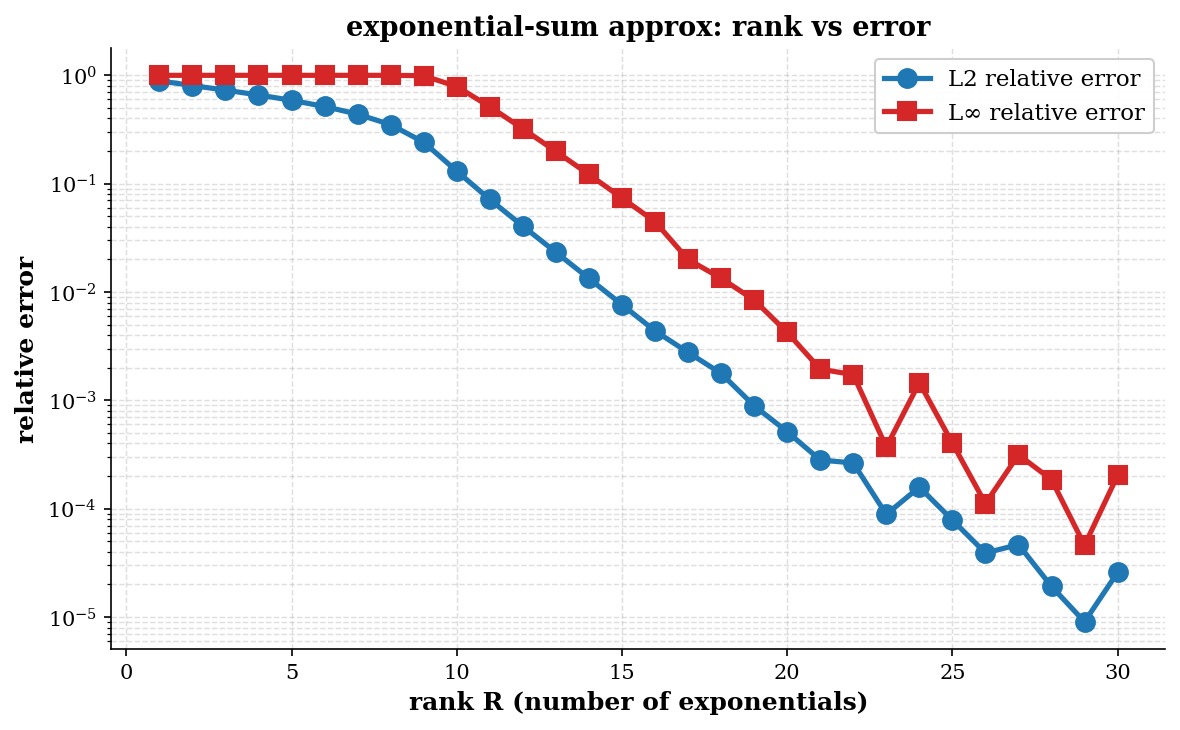

In [24]:
_UNDERFLOW_THRESHOLD = 1e-300


def _masked_loglog(ax, x, y, **kwargs):
    """y > threshold の点のみ loglog プロット（アンダーフロー除外）。"""
    valid = y > _UNDERFLOW_THRESHOLD
    if valid.any():
        ax.loglog(x[valid], y[valid], **kwargs)


def _make_colormap(n: int):
    cmap = plt.get_cmap("viridis")
    return [cmap(i / max(n - 1, 1)) for i in range(n)]


# ---------------------------------------------------------------------------
# 図1 + 図2: 近似カーブ と 点ごとの相対誤差
# ---------------------------------------------------------------------------

def plot_approximation(fits: dict, eval_grid: LogUniformGrid) -> None:
    r_eval = eval_grid.points
    f_true = 1.0 / r_eval
    ranks = sorted(fits.keys())
    colors = _make_colormap(len(ranks))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    ax.loglog(r_eval, f_true, "k-", lw=2.5, label="1/r (true)", zorder=10)

    for color, r in zip(colors, ranks):
        approx = fits[r].evaluate(r_eval)
        _masked_loglog(ax, r_eval, approx, lw=1.6, ls="--",
                       color=color, alpha=0.85, label=f"R={r}")

    ax.set_ylim(f_true.min() * 0.5, f_true.max() * 2.0)
    ax.set_xlabel("r", fontsize=12, fontweight="bold")
    ax.set_ylabel("value", fontsize=12, fontweight="bold")
    ax.set_title("1/r vs exponential-sum approximation", fontsize=13, fontweight="bold")
    ax.grid(True, which="both", alpha=0.4, linestyle="--", linewidth=0.7)
    ax.legend(fontsize=9, loc="best", ncol=2, framealpha=0.95)

    ax2 = axes[1]
    for color, r in zip(colors, ranks):
        approx = fits[r].evaluate(r_eval)
        valid = approx > _UNDERFLOW_THRESHOLD
        if valid.any():
            rel_err = np.abs((approx[valid] - f_true[valid]) / f_true[valid])
            ax2.loglog(r_eval[valid], rel_err, "-", lw=1.6,
                       color=color, alpha=0.9, label=f"R={r}")

    ax2.set_xlabel("r", fontsize=12, fontweight="bold")
    ax2.set_ylabel("relative error |approx - 1/r| / |1/r|",
                   fontsize=12, fontweight="bold")
    ax2.set_title("pointwise relative error", fontsize=13, fontweight="bold")
    ax2.grid(True, which="both", alpha=0.4, linestyle="--", linewidth=0.7)
    ax2.legend(fontsize=9, loc="best", ncol=2, framealpha=0.95)

    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------------------------
# 図3: ランク vs L2 / L∞ 誤差
# ---------------------------------------------------------------------------

def plot_rank_vs_error(fits: dict) -> None:
    ranks = sorted(fits.keys())
    l2_errs = [fits[r].l2_error for r in ranks]
    linf_errs = [fits[r].linf_error for r in ranks]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.semilogy(ranks, l2_errs, "o-", markersize=9, lw=2.5,
                label="L2 relative error", color="C0")
    ax.semilogy(ranks, linf_errs, "s-", markersize=9, lw=2.5,
                label="L∞ relative error", color="C3")
    ax.set_xlabel("rank R (number of exponentials)", fontsize=12, fontweight="bold")
    ax.set_ylabel("relative error", fontsize=12, fontweight="bold")
    ax.set_title("exponential-sum approx: rank vs error",
                 fontsize=13, fontweight="bold")
    ax.grid(True, which="both", alpha=0.4, linestyle="--", linewidth=0.7)
    ax.legend(fontsize=11, loc="best", framealpha=0.95)
    plt.tight_layout()
    plt.show()

plot_approximation(fits, eval_grid)
plot_rank_vs_error(fits)

In [25]:
from src.potential.charge_potential import v_analytic_gaussian
V_analytic = v_analytic_gaussian(R, alpha)

ガウシアン密度を x, y, z 方向の外積和で表す

現在の `rho_grid` に行列を3軸方向から順次作用させる方法は一般的だが、各ステップで3Dテンソル全体を並べ替える。今回の密度はガウシアンなので、

$$
\rho(x,y,z)=\exp[-\alpha(x^2+y^2+z^2)]
=\rho_x(x)\rho_y(y)\rho_z(z)
$$

と分離できる。以降では密度を `(係数, ρx, ρy, ρz)` のリスト、つまりCP形式の外積和として持つ。


In [26]:
from src.potential.separable_density import make_gaussian_density_terms, materialize_density_terms

x_axis = xyz[0, :, 0, 0]
rho_terms = make_gaussian_density_terms(x_axis, alpha)
rho_grid_from_terms = materialize_density_terms(rho_terms)
print(
    "max |rho_grid - separable rho| =",
    np.max(np.abs(rho_grid - rho_grid_from_terms)),
)


max |rho_grid - separable rho| = 2.220446049250313e-16


対角成分の補正 ($1/r$ に対する近傍積分)

クーロンカーネル $1/r$ を離散化する際、同一セル内（$r=0$）の寄与を正しく評価する必要があります。指数和近似では中心での値が有限値 $\sum w_k$ となり、厳密な特異性を表現できません。
そこで、一辺 $dx$ の立方体領域の内部で $1/r$ を積分した解析値を用いて誤差を補正します。

単位立方体 $[-0.5, 0.5]^3$ における $1/r$ の体積積分は約 `2.38` となることが知られています。
これを用いて、対角成分の真の寄与は変数のスケール変換から以下のように求まります。

$$
K_{\text{diag}} = \frac{1}{dx^3} \iiint_{[-dx/2, dx/2]^3} \frac{1}{r} d^3r \approx \frac{2.38}{dx}
$$

実際の計算では、指数和近似がもつ対角成分 $\sum w_k$ と真の寄与 $2.38/dx$ の差分を加えることで近傍の誤差を補正します。

E_analytic(grid) = 1.236971e+01
   R |     1/r L2 | V err (no) | V err (corr) | E err (no) | E err (corr) |     Σw_k
------------------------------------------------------------------------------------------
   1 |  8.887e-01 |  9.989e-01 |    9.998e-01 |  9.844e-01 |    9.967e-01 |   84.190
   2 |  8.046e-01 |  9.978e-01 |    9.991e-01 |  9.684e-01 |    9.867e-01 |  116.825
   3 |  7.297e-01 |  9.921e-01 |    9.935e-01 |  8.848e-01 |    9.072e-01 |  138.864
   4 |  6.586e-01 |  9.723e-01 |    9.734e-01 |  5.954e-01 |    6.209e-01 |  155.913
   5 |  5.881e-01 |  9.252e-01 |    9.255e-01 |  1.016e-01 |    1.297e-01 |  169.982
   6 |  5.156e-01 |  8.305e-01 |    8.303e-01 |  8.913e-02 |    5.879e-02 |  182.047
   7 |  4.381e-01 |  6.310e-01 |    6.310e-01 |  1.994e-02 |    1.236e-02 |  192.663
   8 |  3.505e-01 |  2.654e-01 |    2.653e-01 |  2.271e-02 |    1.135e-02 |  202.174
   9 |  2.413e-01 |  1.305e-01 |    1.301e-01 |  3.964e-02 |    3.979e-03 |  210.825
  10 |  1.306e-01 |  8.300e

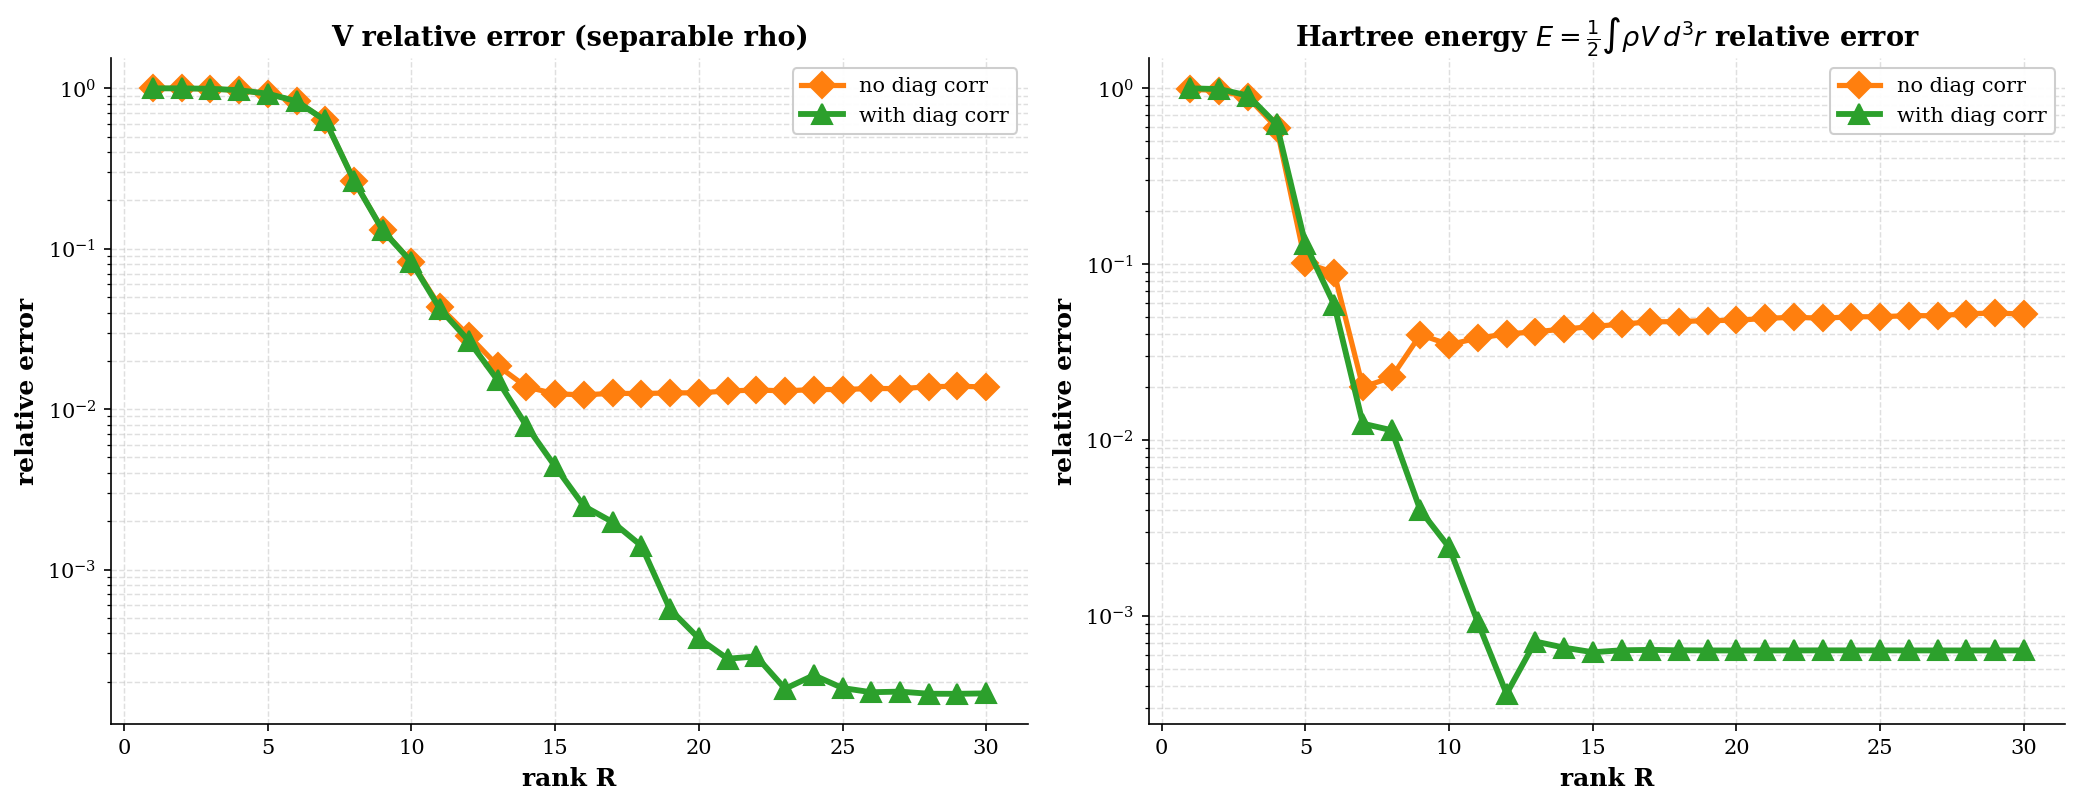

In [27]:
from src.potential.separable_density import apply_exp_sum_to_separable_density

# ===== 各 R に対する V / E 相対誤差 (CP形式のρ + 対角補正あり / なし) =====
x_axis = xyz[0, :, 0, 0]
cell_int_const = 2.38                    # 立方体セル ∫ 1/r d³r / dx²
K_diag_true = cell_int_const / dx

# 解析エネルギー: E = (1/2) ∫ ρ V d³r を同じグリッド上のミッドポイント則で評価
E_analytic = 0.5 * np.sum(rho_grid * V_analytic) * dx**3

err_v_no_corr   = {}
err_v_with_corr = {}
err_e_no_corr   = {}
err_e_with_corr = {}

for r, fit in fits.items():
    V_no = apply_exp_sum_to_separable_density(
        fit=fit,
        x_axis=x_axis,
        density_terms=rho_terms,
        dx=dx,
        diag_coeff=0.0,
    )
    V_corr = apply_exp_sum_to_separable_density(
        fit=fit,
        x_axis=x_axis,
        density_terms=rho_terms,
        dx=dx,
        diag_coeff=K_diag_true - fit.weights.sum(),
    )

    err_v_no_corr[r]   = np.linalg.norm(V_no   - V_analytic) / np.linalg.norm(V_analytic)
    err_v_with_corr[r] = np.linalg.norm(V_corr - V_analytic) / np.linalg.norm(V_analytic)

    E_no   = 0.5 * np.sum(rho_grid * V_no)   * dx**3
    E_corr = 0.5 * np.sum(rho_grid * V_corr) * dx**3
    err_e_no_corr[r]   = abs(E_no   - E_analytic) / abs(E_analytic)
    err_e_with_corr[r] = abs(E_corr - E_analytic) / abs(E_analytic)

# ----- 表 -----
print(f"E_analytic(grid) = {E_analytic:.6e}")
print(f"{'R':>4s} | {'1/r L2':>10s} | "
      f"{'V err (no)':>10s} | {'V err (corr)':>12s} | "
      f"{'E err (no)':>10s} | {'E err (corr)':>12s} | {'Σw_k':>8s}")
print("-" * 90)
for r in sorted(fits):
    print(
        f"{r:>4d} | {fits[r].l2_error:>10.3e} | "
        f"{err_v_no_corr[r]:>10.3e} | {err_v_with_corr[r]:>12.3e} | "
        f"{err_e_no_corr[r]:>10.3e} | {err_e_with_corr[r]:>12.3e} | "
        f"{fits[r].weights.sum():>8.3f}"
    )

# ----- 図 -----
ranks_sorted = sorted(fits.keys())
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

ax = axes[0]
ax.semilogy(ranks_sorted, [err_v_no_corr[r]   for r in ranks_sorted],
            'D-',  markersize=9, lw=2.5, label='no diag corr',   color='C1')
ax.semilogy(ranks_sorted, [err_v_with_corr[r] for r in ranks_sorted],
            '^-',  markersize=10, lw=2.8, label='with diag corr', color='C2')
ax.set_xlabel('rank R', fontsize=12, fontweight='bold')
ax.set_ylabel('relative error', fontsize=12, fontweight='bold')
ax.set_title('V relative error (separable rho)', fontsize=13, fontweight='bold')
ax.grid(True, which='both', alpha=0.4, linestyle='--', linewidth=0.7)
ax.legend(fontsize=10, loc='best', framealpha=0.95)

ax = axes[1]
ax.semilogy(ranks_sorted, [err_e_no_corr[r]   for r in ranks_sorted],
            'D-',  markersize=9, lw=2.5, label='no diag corr',   color='C1')
ax.semilogy(ranks_sorted, [err_e_with_corr[r] for r in ranks_sorted],
            '^-',  markersize=10, lw=2.8, label='with diag corr', color='C2')
ax.set_xlabel('rank R', fontsize=12, fontweight='bold')
ax.set_ylabel('relative error', fontsize=12, fontweight='bold')
ax.set_title(r'Hartree energy $E=\frac{1}{2}\int\rho V\,d^3r$ relative error',
             fontsize=13, fontweight='bold')
ax.grid(True, which='both', alpha=0.4, linestyle='--', linewidth=0.7)
ax.legend(fontsize=10, loc='best', framealpha=0.95)

plt.tight_layout()
plt.show()


なぜ Rank 15 以降でエネルギーの誤差が打ち止め（プラトー）になるのか？

グリッド分割幅 ($dx$) による離散化誤差（数値積分の限界）が主な原因。

現在の計算では $N=151, L=20$ と設定されているため、グリッドの間隔は $dx \approx 0.132$ となります。エネルギーの計算は配列の単純な和 `np.sum(...) * dx**3`で行われています（リーマン和による区分求積法）。

Rank（指数関数の項数）を増やせば、擬似的な $1/r$ の関数自体はいくらでも真の関数に近づきますが、それを離散的なグリッド上で体積積分する際の「数値積分としての限界」が存在します。この離散化に起因する $O(dx^2)$ レベルの誤差が $10^{-3} \sim 10^{-4}$ のスケールにあるため、これ以上 Rank を上げて近似関数の質を良くしても、全体のエネルギー精度は向上しなくなる

## N を変えた離散化誤差の確認

プラトーが指数和近似ではなく離散化誤差に支配されているかを見るため、複数の `N` で同じ計算を行う。
参照値として連続系のガウシアン自己エネルギー

$$
E_{\mathrm{exact}}=\frac{\pi^{5/2}}{\sqrt{2}\,\alpha^{5/2}}
$$

との相対誤差を `dx` の関数としてプロットし、十分大きい `R` での誤差床が `dx` とともに減少すれば、プラトーは離散化誤差が主因だと判断できる。

exp-sum energy error vs continuous exact
   R |     N |         dx |   err vs exact
------------------------------------------
  11 |    51 | 3.9216e-01 |      5.813e-03
  11 |    75 | 2.6667e-01 |      2.764e-03
  11 |   101 | 1.9802e-01 |      1.723e-03
  11 |   151 | 1.3245e-01 |      9.174e-04
  15 |    51 | 3.9216e-01 |      5.336e-03
  15 |    75 | 2.6667e-01 |      2.509e-03
  15 |   101 | 1.9802e-01 |      1.401e-03
  15 |   151 | 1.3245e-01 |      6.203e-04
  20 |    51 | 3.9216e-01 |      5.338e-03
  20 |    75 | 2.6667e-01 |      2.537e-03
  20 |   101 | 1.9802e-01 |      1.411e-03
  20 |   151 | 1.3245e-01 |      6.346e-04
  30 |    51 | 3.9216e-01 |      5.342e-03
  30 |    75 | 2.6667e-01 |      2.533e-03
  30 |   101 | 1.9802e-01 |      1.411e-03
  30 |   151 | 1.3245e-01 |      6.351e-04


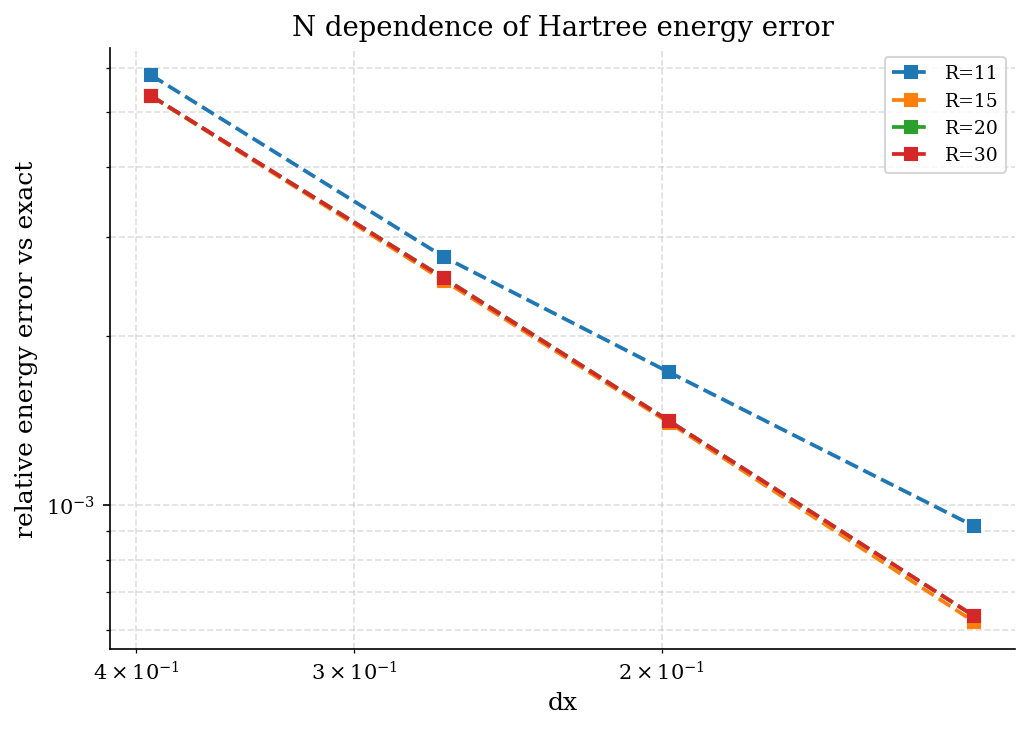

In [28]:
import importlib
from src.potential import gaussian_discretization
gaussian_discretization = importlib.reload(gaussian_discretization)
compare_exp_sum_discretization = gaussian_discretization.compare_exp_sum_discretization

N_values = [51, 75, 101, 151]
ranks_to_check = [11, 15, 20, 30]
rank_rows_by_R = compare_exp_sum_discretization(
    N_values=N_values,
    L=L,
    alpha=alpha,
    fits=fits,
    ranks=ranks_to_check,
)

print("exp-sum energy error vs continuous exact")
print(f"{'R':>4s} | {'N':>5s} | {'dx':>10s} | {'err vs exact':>14s}")
print("-" * 42)
for rank in ranks_to_check:
    for row in rank_rows_by_R[rank]:
        print(
            f"{rank:>4d} | {row.N:>5d} | {row.dx:>10.4e} | "
            f"{row.err_vs_cont_exact:>14.3e}"
        )

fig, ax = plt.subplots(figsize=(7, 5))
dx_values = np.array([row.dx for row in rank_rows_by_R[ranks_to_check[0]]])
for rank in ranks_to_check:
    rank_rel = np.array([row.err_vs_cont_exact for row in rank_rows_by_R[rank]])
    ax.loglog(dx_values, rank_rel, 's--', lw=1.8, label=f'R={rank}')
ax.invert_xaxis()
ax.set_xlabel('dx')
ax.set_ylabel('relative energy error vs exact')
ax.set_title('N dependence of Hartree energy error')
ax.grid(True, which='both', alpha=0.4, ls='--')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

15以上近似を増やしてもあまり寄与しなそう

Loaded 1D kernel decompositions -> /home/ikuta/region_PJ/data/npy/rpca_kernels/L20_rmin1e-02_rmax34.641_n2000_nonneg1_iter200000_R01-30_count30/N151_L20_R11_rank37_iter2000_tol1e-06
Loaded RPCA error sweep results -> /home/ikuta/region_PJ/data/npy/rpca_error_sweep/L20_rmin1e-02_rmax34.641_n2000_nonneg1_iter200000_R01-30_count30/N151_L20_R11_rank37_iter2000_tol1e-06/r01-25


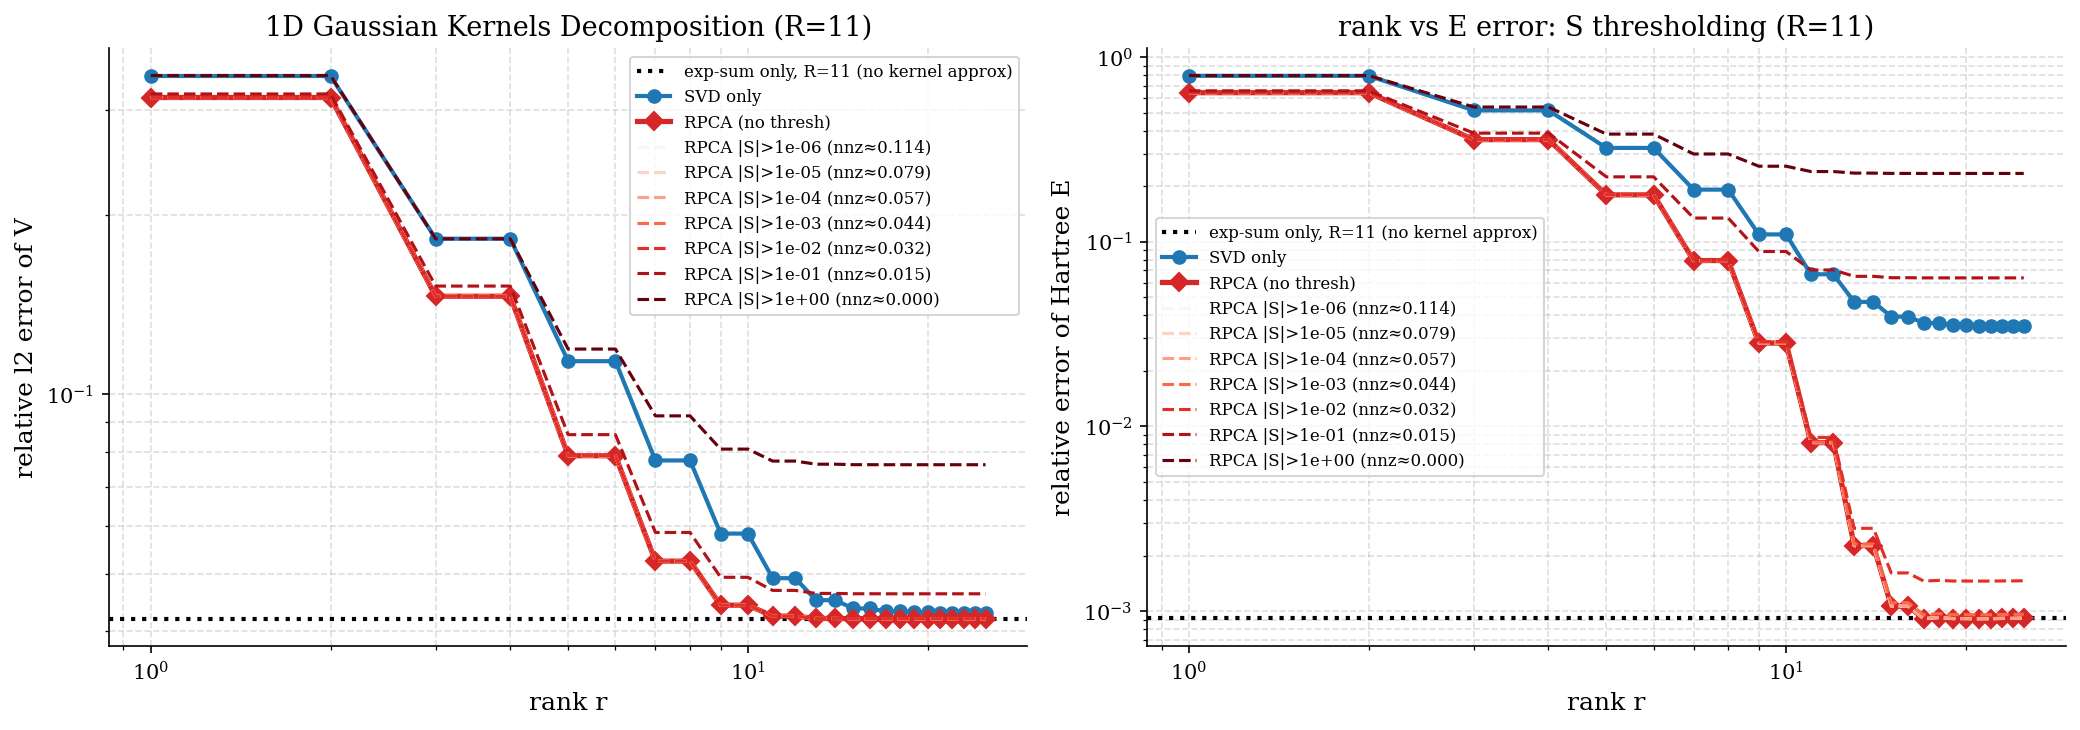

In [29]:
from src.utils.cache import load_rpca_1d_list
from src.utils.cache import rpca_label as make_rpca_label
import importlib

from src.potential import gaussian_discretization

compute_rpca_error_sweep = gaussian_discretization.compute_rpca_error_sweep

# ---- scripts/run_rpca_kernels.py が保存した .npy を読み込む ----
# notebook 上では重い RPCA / SVD 分解を行わない。計算が必要な場合は、
# Slurm などで `python scripts/run_rpca_kernels.py --compute` を実行する。
exp_sum_R = 11
fit = fits[exp_sum_R]

svd_ranks = list(range(1, 26))
rpca_rank = N // 4
rpca_max_iter = 2000
rpca_tol = 1e-6
rpca_label = make_rpca_label(
    N=N,
    L=L,
    exp_sum_R=exp_sum_R,
    rpca_rank=rpca_rank,
    rpca_max_iter=rpca_max_iter,
    rpca_tol=rpca_tol,
)

rpca_dir = (
    PROJECT_ROOT
    / "data"
    / "npy"
    / "rpca_kernels"
    / exp_sum_label
    / rpca_label
)
if not rpca_dir.exists():
    raise FileNotFoundError(
        f"RPCA カーネルの .npy ディレクトリが見つかりません: {rpca_dir}\n"
        "先に計算用 PC / Slurm で "
        "`python scripts/run_rpca_kernels.py --compute` を実行してください。"
    )

K_1d_list = [
    np.load(rpca_dir / f"k{k:02d}_K1d.npy")
    for k in range(fit.rank)
]
RPCA_1d_list = load_rpca_1d_list(rpca_dir, n_terms=fit.rank)

thresholds = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0]
rank_label = f"r{min(svd_ranks):02d}-{max(svd_ranks):02d}"
sweep_dir = (
    PROJECT_ROOT
    / "data"
    / "npy"
    / "rpca_error_sweep"
    / exp_sum_label
    / rpca_label
    / rank_label
)


def load_rpca_error_sweep_results(sweep_dir, thresholds):
    """scripts/run_rpca_error_sweep.py の .npy 出力を読む。"""
    loaded = {
        "errors_v_svd_only": np.load(sweep_dir / "errors_v_svd_only.npy"),
        "errors_e_svd_only": np.load(sweep_dir / "errors_e_svd_only.npy"),
        "errors_v_rpca": np.load(sweep_dir / "errors_v_rpca.npy"),
        "errors_e_rpca": np.load(sweep_dir / "errors_e_rpca.npy"),
        "errors_v_rpca_thresh": {},
        "errors_e_rpca_thresh": {},
    }
    for thresh in thresholds:
        key = f"{thresh:.0e}"
        loaded["errors_v_rpca_thresh"][key] = np.load(
            sweep_dir / f"errors_v_rpca_thresh_{key}.npy"
        )
        loaded["errors_e_rpca_thresh"][key] = np.load(
            sweep_dir / f"errors_e_rpca_thresh_{key}.npy"
        )
    return loaded


required_sweep_files = [
    sweep_dir / "svd_ranks.npy",
    sweep_dir / "thresholds.npy",
    sweep_dir / "errors_v_svd_only.npy",
    sweep_dir / "errors_e_svd_only.npy",
    sweep_dir / "errors_v_rpca.npy",
    sweep_dir / "errors_e_rpca.npy",
]
for thresh in thresholds:
    key = f"{thresh:.0e}"
    required_sweep_files.append(
        sweep_dir / f"errors_v_rpca_thresh_{key}.npy"
    )
    required_sweep_files.append(
        sweep_dir / f"errors_e_rpca_thresh_{key}.npy"
    )

print(f"Loaded 1D kernel decompositions -> {rpca_dir}")
if all(path.exists() for path in required_sweep_files):
    saved_svd_ranks = np.load(sweep_dir / "svd_ranks.npy").tolist()
    saved_thresholds = np.load(sweep_dir / "thresholds.npy")
    if saved_svd_ranks == svd_ranks and np.allclose(
        saved_thresholds,
        thresholds,
    ):
        results = load_rpca_error_sweep_results(sweep_dir, thresholds)
        print(f"Loaded RPCA error sweep results -> {sweep_dir}")
    else:
        print("Saved RPCA sweep condition differs; recalculating...")
        results = compute_rpca_error_sweep(
            fit=fit,
            rpca_1d_list=RPCA_1d_list,
            rho_grid=rho_grid,
            v_analytic=V_analytic,
            dx=dx,
            k_diag_true=K_diag_true,
            svd_ranks=svd_ranks,
            thresholds=thresholds,
        )
else:
    print("Saved RPCA sweep results were not found; recalculating...")
    results = compute_rpca_error_sweep(
        fit=fit,
        rpca_1d_list=RPCA_1d_list,
        rho_grid=rho_grid,
        v_analytic=V_analytic,
        dx=dx,
        k_diag_true=K_diag_true,
        svd_ranks=svd_ranks,
        thresholds=thresholds,
    )
errors_v_svd_only = results["errors_v_svd_only"].tolist()
errors_e_svd_only = results["errors_e_svd_only"].tolist()
errors_v_rpca = results["errors_v_rpca"].tolist()
errors_e_rpca = results["errors_e_rpca"].tolist()
errors_v_rpca_thresh = {
    thresh: results["errors_v_rpca_thresh"][f"{thresh:.0e}"].tolist()
    for thresh in thresholds
}
errors_e_rpca_thresh = {
    thresh: results["errors_e_rpca_thresh"][f"{thresh:.0e}"].tolist()
    for thresh in thresholds
}

# プロット
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# colors / linestyles for thresholds
cmap = plt.get_cmap("Reds")
colors = [cmap(i / max(len(thresholds) - 1, 1)) for i in range(len(thresholds))]

# 指数和近似のみ（カーネル近似なし）の参照誤差を点線で表示
ref_label = f'exp-sum only, R={exp_sum_R} (no kernel approx)'
axes[0].axhline(err_v_with_corr[exp_sum_R], ls=':', lw=2.0, color='k', label=ref_label)
axes[1].axhline(err_e_with_corr[exp_sum_R], ls=':', lw=2.0, color='k', label=ref_label)

axes[0].loglog(svd_ranks, errors_v_svd_only, 'o-', lw=2, label='SVD only')
axes[0].loglog(svd_ranks, errors_v_rpca, 'D-', lw=2.5, color='C3', label='RPCA (no thresh)')
for i, thresh in enumerate(thresholds):
    # compute median nnz ratio for legend roughly
    mean_nnz = np.mean([np.count_nonzero(np.abs(k_data['S_1d']) > thresh) / k_data['S_1d'].size for k_data in RPCA_1d_list])
    axes[0].loglog(svd_ranks, errors_v_rpca_thresh[thresh], '--', color=colors[i], label=f'RPCA |S|>{thresh:.0e} (nnz≈{mean_nnz:.3f})')

axes[0].set_xlabel('rank r', fontsize=12)
axes[0].set_ylabel('relative l2 error of V', fontsize=12)
axes[0].set_title(f'1D Gaussian Kernels Decomposition (R={exp_sum_R})', fontsize=13)
axes[0].grid(True, which='both', alpha=0.4, ls='--')
axes[0].legend(fontsize=8, loc='best')

axes[1].loglog(svd_ranks, errors_e_svd_only, 'o-', lw=2, label='SVD only')
axes[1].loglog(svd_ranks, errors_e_rpca, 'D-', lw=2.5, color='C3', label='RPCA (no thresh)')
for i, thresh in enumerate(thresholds):
    mean_nnz = np.mean([np.count_nonzero(np.abs(k_data['S_1d']) > thresh) / k_data['S_1d'].size for k_data in RPCA_1d_list])
    axes[1].loglog(svd_ranks, errors_e_rpca_thresh[thresh], '--', color=colors[i], label=f'RPCA |S|>{thresh:.0e} (nnz≈{mean_nnz:.3f})')

axes[1].set_xlabel('rank r', fontsize=12)
axes[1].set_ylabel('relative error of Hartree E', fontsize=12)
axes[1].set_title(f'rank vs E error: S thresholding (R={exp_sum_R})', fontsize=13)
axes[1].grid(True, which='both', alpha=0.4, ls='--')
axes[1].legend(fontsize=8, loc='best')

plt.tight_layout()
plt.show()
plt.show()

Loaded 11 terms from N151_L20_R11_rank37_iter2000_tol1e-06

  k     |S|_max  nnz@1e-06  nnz@1e-05  nnz@1e-04  nnz@1e-03  nnz@1e-02  nnz@1e-01
----------------------------------------------------------------------------------------
  0   2.061e-01      0.0889      0.0626      0.0440      0.0210      0.0117      0.0021
  1   9.937e-01      0.5162      0.3518      0.2231      0.1622      0.1224      0.0721
  2   1.000e+00      0.0587      0.0587      0.0458      0.0458      0.0328      0.0198
  3   1.000e+00      0.0198      0.0198      0.0198      0.0198      0.0198      0.0066
  4   1.000e+00      0.0066      0.0066      0.0066      0.0066      0.0066      0.0066
  5   1.000e+00      0.0066      0.0066      0.0066      0.0066      0.0066      0.0066
  6   1.000e+00      0.0066      0.0066      0.0066      0.0066      0.0066      0.0066
  7   1.000e+00      0.0066      0.0066      0.0066      0.0066      0.0066      0.0066
  8   1.000e+00      0.0066      0.0066      0.0066      0.0066  

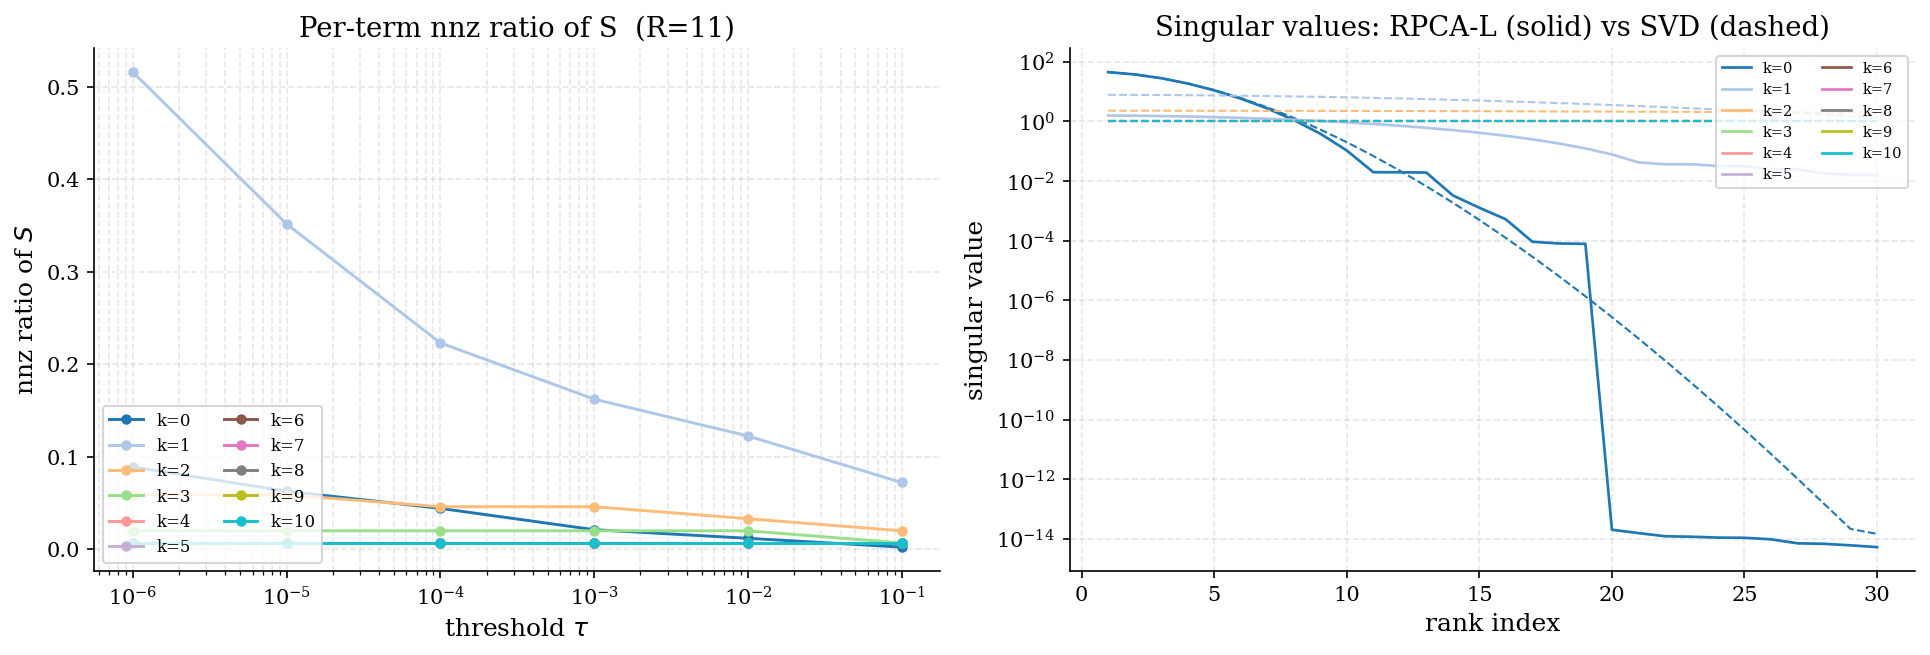

In [30]:
# ===== RPCA per-term 分析: 各 k の S 非ゼロ率 / L 特異値 =====
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from src.utils.cache import (
    load_rpca_1d_list,
    rpca_label as make_rpca_label,
    exp_sum_label as make_exp_sum_label,
)

_N, _L, _exp_sum_R = 151, 20, 11

_PROJECT_ROOT = Path.cwd()
if not (_PROJECT_ROOT / "data").exists() and (_PROJECT_ROOT.parent / "data").exists():
    _PROJECT_ROOT = _PROJECT_ROOT.parent

# rpca_kernels は rmin=1e-3 ベースのパスに存在
_es_label_rpca = make_exp_sum_label(
    L=_L, ranks=list(range(1, 31)), nonneg=True,
    max_iter=200000, n_points=2000,
    r_min=1e-3, r_max=np.sqrt(3) * _L,
)
_rpca_lbl = make_rpca_label(
    N=_N, L=_L, exp_sum_R=_exp_sum_R,
    rpca_rank=_N // 4, rpca_max_iter=2000, rpca_tol=1e-6,
)
_rpca_dir = _PROJECT_ROOT / "data" / "npy" / "rpca_kernels" / _es_label_rpca / _rpca_lbl
_rpca_list = load_rpca_1d_list(_rpca_dir, n_terms=_exp_sum_R)
_K = len(_rpca_list)
print(f"Loaded {_K} terms from {_rpca_dir.name}")

_thresholds = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1]

# S 非ゼロ率: shape (K, len(thresholds))
_nnz = np.array([
    [np.count_nonzero(np.abs(k["S_1d"]) > t) / k["S_1d"].size
     for t in _thresholds]
    for k in _rpca_list
])

_s_max = np.array([np.abs(k["S_1d"]).max() for k in _rpca_list])
_sv_L  = np.array([k["S_L"] for k in _rpca_list])  # (K, N): L の特異値
_sv_s  = np.array([k["S_s"] for k in _rpca_list])  # (K, N): SVD の特異値

# ---- 数値表 ----
print(f"\n{'k':>3}  {'|S|_max':>10}  " +
      "  ".join(f"nnz@{t:.0e}" for t in _thresholds))
print("-" * (16 + 12 * len(_thresholds)))
for k in range(_K):
    row = "  ".join(f"{_nnz[k, j]:>10.4f}" for j in range(len(_thresholds)))
    print(f"{k:>3}  {_s_max[k]:>10.3e}  {row}")

# ---- プロット ----
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
_cmap = plt.get_cmap("tab20")

# 左: per-term S 非ゼロ率 vs 閾値
ax = axes[0]
for k in range(_K):
    ax.semilogx(_thresholds, _nnz[k], "o-", lw=1.4, ms=4,
                color=_cmap(k / _K), label=f"k={k}")
ax.set_xlabel(r"threshold $\tau$")
ax.set_ylabel("nnz ratio of $S$")
ax.set_title(f"Per-term nnz ratio of S  (R={_exp_sum_R})")
ax.grid(True, which="both", alpha=0.3, ls="--")
ax.legend(fontsize=8, ncol=2, loc="lower left")

# 右: per-term 特異値減衰 (L 実線 / SVD 破線)
ax = axes[1]
r_show = min(30, _sv_L.shape[1])
for k in range(_K):
    c = _cmap(k / _K)
    ax.semilogy(range(1, r_show + 1), _sv_L[k, :r_show],
                "-",  lw=1.3, color=c, label=f"k={k}")
    ax.semilogy(range(1, r_show + 1), _sv_s[k, :r_show],
                "--", lw=1.0, color=c)
ax.set_xlabel("rank index")
ax.set_ylabel("singular value")
ax.set_title("Singular values: RPCA-L (solid) vs SVD (dashed)")
ax.grid(True, which="both", alpha=0.3, ls="--")
ax.legend(fontsize=7, ncol=2, loc="upper right")

plt.tight_layout()
plt.show()


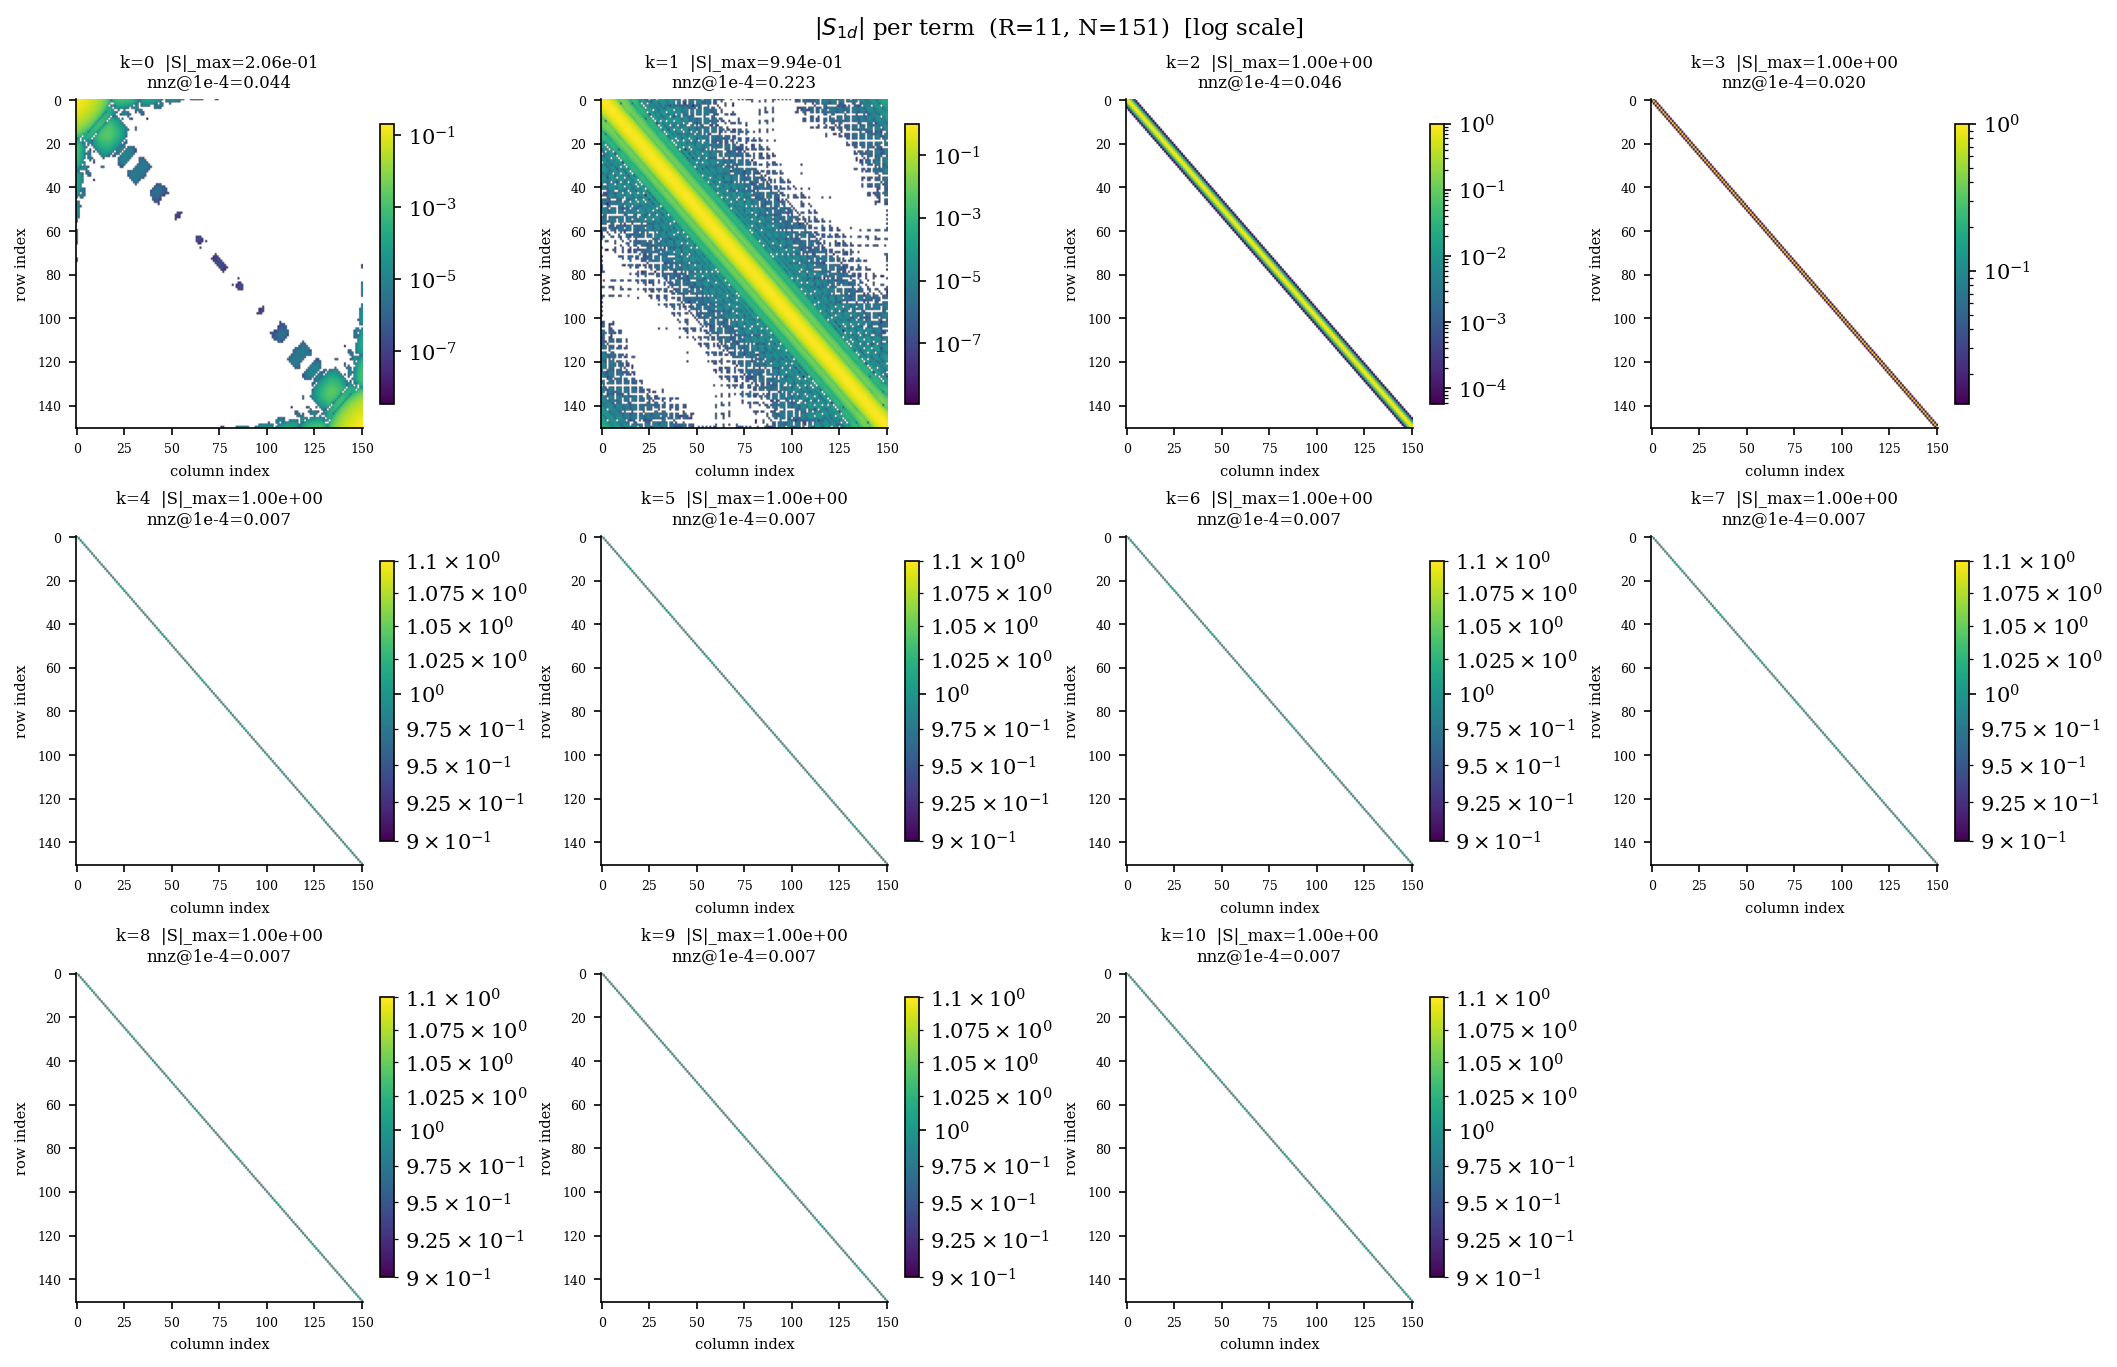

In [31]:
# ===== RPCA per-term 分析: 各 k の S_1d ヒートマップ (絶対値 / log スケール) =====
# _rpca_list / _K / _N は前セルで定義済み
from matplotlib.colors import LogNorm

_ncols = 4
_nrows = (_K + _ncols - 1) // _ncols

fig, axes = plt.subplots(
    _nrows, _ncols,
    figsize=(3.5 * _ncols, 3.0 * _nrows),
    constrained_layout=True,
)
axes = np.array(axes).reshape(-1)

for k in range(_K):
    S_abs = np.abs(_rpca_list[k]["S_1d"])  # shape (N, N)
    ax = axes[k]
    vmax = float(S_abs.max()) or 1.0
    vmin = float(S_abs[S_abs > 0].min()) if S_abs.any() else vmax * 1e-6
    norm = LogNorm(vmin=vmin, vmax=vmax)
    im = ax.imshow(
        S_abs, aspect="auto", cmap="viridis",
        norm=norm, origin="upper",
    )
    plt.colorbar(im, ax=ax, shrink=0.85, pad=0.02)
    nnz_1e4 = np.count_nonzero(S_abs > 1e-4) / S_abs.size
    ax.set_title(
        f"k={k}  |S|_max={vmax:.2e}\nnnz@1e-4={nnz_1e4:.3f}",
        fontsize=8,
    )
    ax.set_xlabel("column index", fontsize=7)
    ax.set_ylabel("row index", fontsize=7)
    ax.tick_params(labelsize=6)

for k in range(_K, len(axes)):
    axes[k].set_visible(False)

fig.suptitle(f"$|S_{{1d}}|$ per term  (R={_K}, N={_N})  [log scale]", fontsize=11)
plt.show()


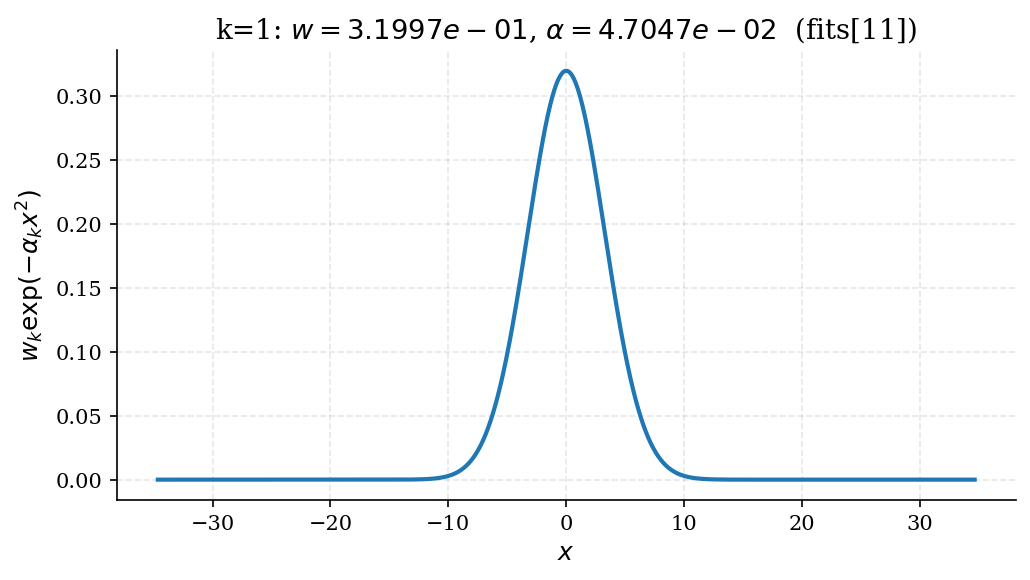

In [32]:
# ===== fits[11] の k=1 項を 1D でそのまま図示 =====
_k = 1
_a = fits[11].alphas[_k]
_w = fits[11].weights[_k]

_x = np.linspace(-r_max, r_max, 1000)
_y = _w * np.exp(-_a * _x**2)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(_x, _y, lw=2)
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$w_k \exp(-\alpha_k x^2)$")
ax.set_title(
    rf"k={_k}: $w={_w:.4e}$, $\alpha={_a:.4e}$"
    f"  (fits[11])"
)
ax.grid(True, alpha=0.3, ls="--")
plt.tight_layout()
plt.show()


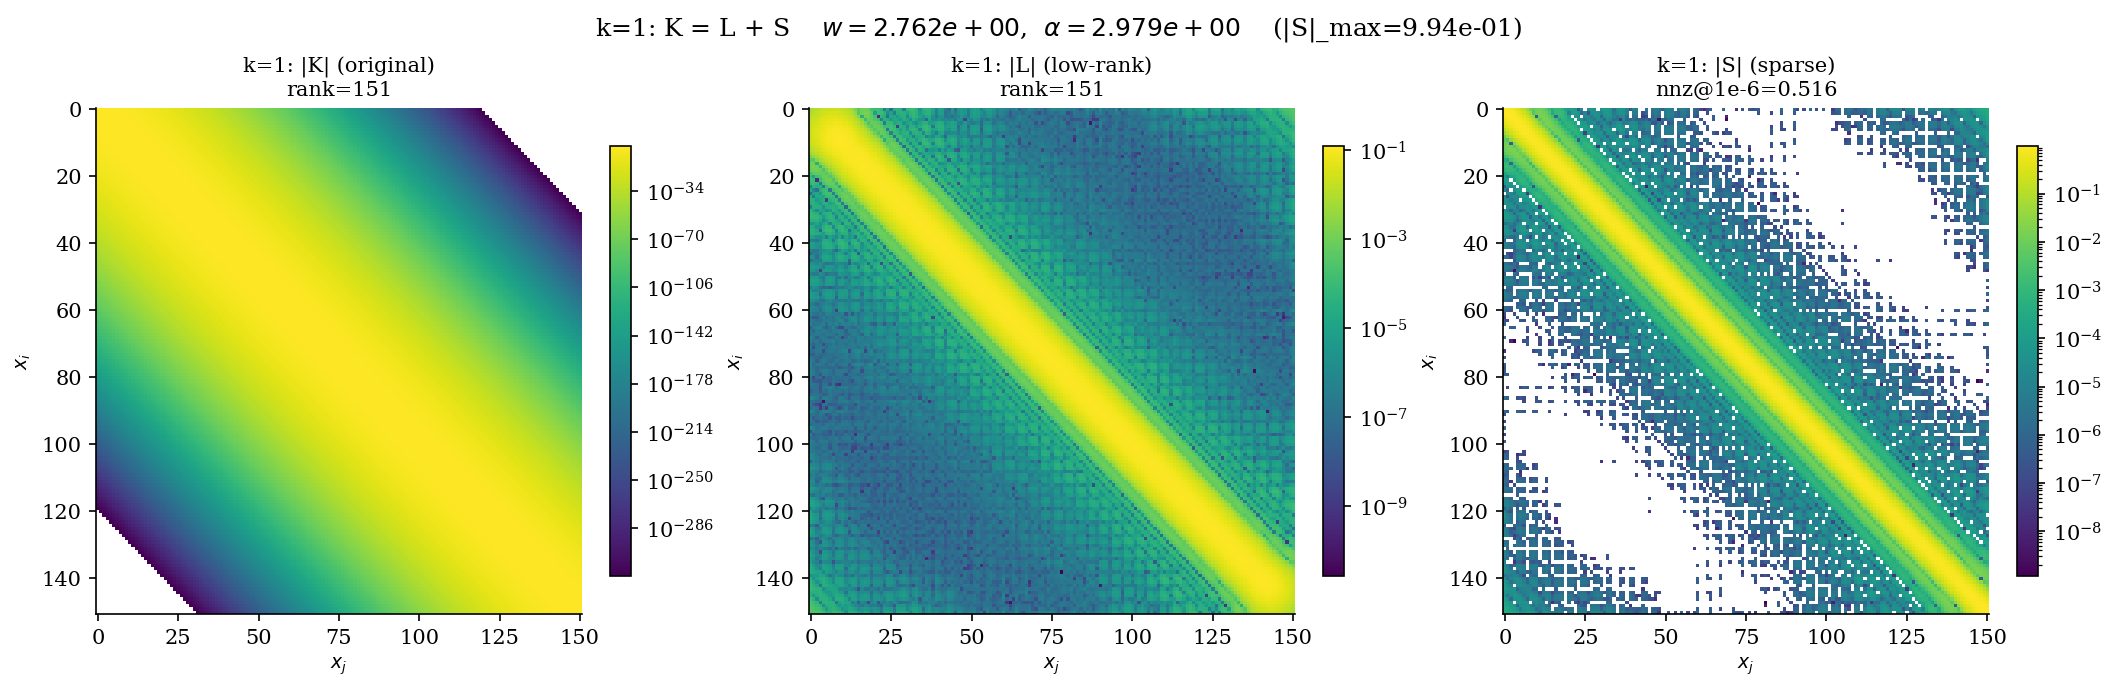

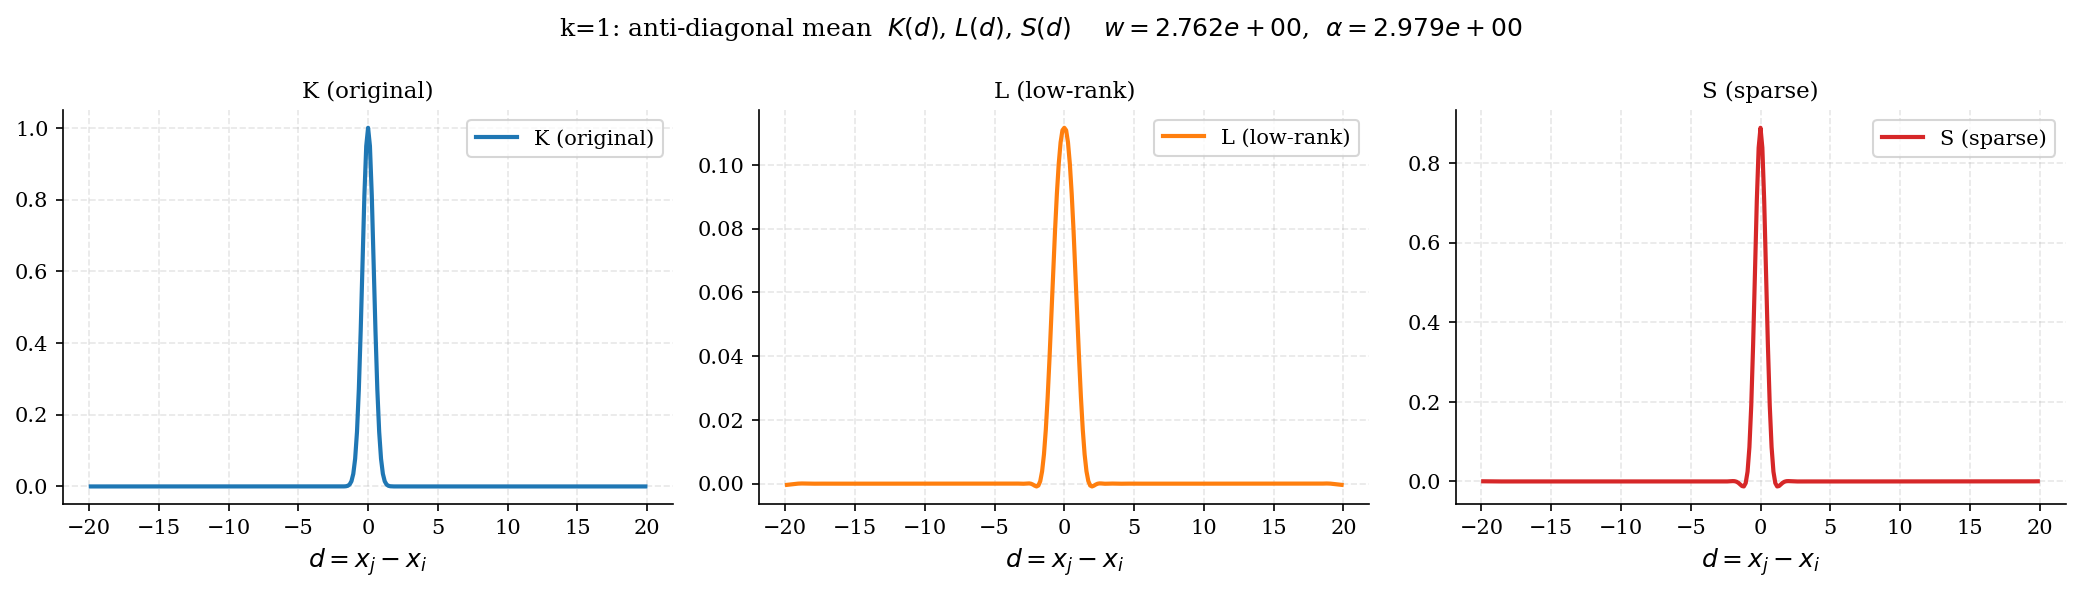

In [33]:
# ===== 1D カーネル RPCA 分解 (K, L, S) の可視化関数 =====
# _rpca_list / _rpca_dir / _es_label_rpca / _exp_sum_R は rpca-perterm-analysis セルで定義済み
from matplotlib.colors import LogNorm

# r_min=1e-3 ベースの exp-sum fit を読み込む
_es_dir_rpca  = _PROJECT_ROOT / "data" / "npy" / "exp_sum" / _es_label_rpca
_alphas_rpca  = np.load(_es_dir_rpca / f"R{_exp_sum_R:02d}_alphas.npy")
_weights_rpca = np.load(_es_dir_rpca / f"R{_exp_sum_R:02d}_weights.npy")


def _antidiag_mean(mat: np.ndarray) -> np.ndarray:
    """anti-diagonal (d = j - i) mean of mat[i, j]."""
    N = mat.shape[0]
    return np.array([mat.diagonal(d).mean() for d in range(-(N - 1), N)])


def plot_rpca_kernel_1d(k: int) -> None:
    """k 番目の 1D カーネルの RPCA 分解 (K, L, S) を可視化する。

    Parameters
    ----------
    k : int
        指数和の項インデックス (0 <= k < exp_sum_R)。
    """
    K_1d = np.load(_rpca_dir / f"k{k:02d}_K1d.npy")
    kd   = _rpca_list[k]
    L_1d = (kd['U_L'] * kd['S_L']) @ kd['Vt_L']
    S_1d = kd['S_1d']

    alpha_k = _alphas_rpca[k]
    w_k     = _weights_rpca[k]
    param_str = rf'$w={w_k:.3e}$,  $\alpha={alpha_k:.3e}$'

    # ---- 図1: ヒートマップ ----
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), constrained_layout=True)
    for ax, mat, title, show_nnz in zip(
        axes,
        [np.abs(K_1d), np.abs(L_1d), np.abs(S_1d)],
        ['|K| (original)', '|L| (low-rank)', '|S| (sparse)'],
        [False, False, True],
    ):
        vmax = float(mat.max()) or 1.0
        pos  = mat[mat > 0]
        vmin = float(pos.min()) if pos.size else vmax * 1e-6
        im = ax.imshow(mat, aspect='auto', cmap='viridis',
                       norm=LogNorm(vmin=vmin, vmax=vmax), origin='upper')
        plt.colorbar(im, ax=ax, shrink=0.85, pad=0.02)
        subtitle = f'nnz@1e-6={np.count_nonzero(mat > 1e-6) / mat.size:.3f}' \
                   if show_nnz else f'rank={np.linalg.matrix_rank(kd["U_L"])}'
        ax.set_title(f'k={k}: {title}\n{subtitle}', fontsize=10)
        ax.set_xlabel('$x_j$', fontsize=9)
        ax.set_ylabel('$x_i$', fontsize=9)
    fig.suptitle(f'k={k}: K = L + S    {param_str}    (|S|_max={np.abs(S_1d).max():.2e})',
                 fontsize=12)
    plt.show()

    # ---- 図2: anti-diagonal mean (1D representation) ----
    N = K_1d.shape[0]
    d_axis = np.arange(-(N - 1), N) * dx

    K_avg = _antidiag_mean(K_1d)
    L_avg = _antidiag_mean(L_1d)
    S_avg = _antidiag_mean(S_1d)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4.0))
    for ax, avg, label, color in zip(
        axes,
        [K_avg, L_avg, S_avg],
        ['K (original)', 'L (low-rank)', 'S (sparse)'],
        ['C0', 'C1', 'C3'],
    ):
        ax.plot(d_axis, avg, lw=2.0, color=color, label=label)
        ax.set_xlabel(r'$d = x_j - x_i$', fontsize=12)
        ax.set_title(label, fontsize=11)
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3, ls='--')
    fig.suptitle(
        f'k={k}: anti-diagonal mean  $K(d)$, $L(d)$, $S(d)$    {param_str}',
        fontsize=12,
    )
    plt.tight_layout()
    plt.show()


plot_rpca_kernel_1d(k=1)

## 計算時間の比較 (3D 指数和近似 / PyTorch バックエンド)

1D の議論を3次元に拡張する。
1つの Gaussian カーネル `K (N×N)` を `ρ (N,N,N)` の各軸に作用させるコストを測る。
アルゴリズム間の純粋な計算量の差を評価するため、すべての経路を **PyTorch テンソル演算** に統一して計測する。

- **full**: そのまま N×N の `K` を tensordot で適用。各軸 O(N⁴)。
- **low-rank (順序ミス)**: `K_r = (U_r Σ_r) @ V_rᵀ` を **再構成してから** `tensordot` する。N×N に戻ってしまうので O(N⁴) に逆戻り。
- **low-rank (正しい順序)**: `K_r` を組み立てず、`V_rᵀ` を先にテンソルに作用させて軸の次元を r に落とし、最後に `U_r` で戻す mode-n product。**O(rN³)**。
- **rPCA**: `K ≈ L + S`。`L` は rank-r で正しい順序。`S` は閾値でゼロ化した後、非ゼロ率が 10% 以下なら **PyTorch の Sparse CSR テンソル (`torch.sparse.mm`)** を使用、そうでなければ dense tensordot を使用する。

> **注**: NumPy / SciPy (CPU) 同士等の比較では、関数や機能ごとのマルチスレッド（OpenMP）の使われ方やオーバーヘッドが異なり、純粋なアルゴリズムの差を評価しにくくなることがある。本計測ではすべての経路を PyTorch のテンソル操作にそろえることで、ライブラリバックエンドの実装差を排除した公平なパフォーマンス比較を行っている。


In [38]:
# ---- タイミング結果の読み込み (run_timing_benchmark.py の出力) ----
from pathlib import Path
from src.utils.cache import exp_sum_label as _exp_sum_label
from src.utils.cache import rpca_label as _rpca_label
from src.approximation.timing import timing_sweep_label
from src import experiment_config as cfg
import json

try:
    PROJECT_ROOT
except NameError:
    PROJECT_ROOT = Path.cwd()
    if (
        not (PROJECT_ROOT / "data").exists()
        and (PROJECT_ROOT.parent / "data").exists()
    ):
        PROJECT_ROOT = PROJECT_ROOT.parent

_es_label = _exp_sum_label(
    L=cfg.L(),
    ranks=cfg.exp_sum_ranks(),
    nonneg=cfg.exp_sum_nonneg(),
    max_iter=cfg.exp_sum_max_iter(),
    n_points=cfg.exp_sum_n_points(),
    r_min=cfg.exp_sum_r_min(),
    r_max=np.sqrt(3) * cfg.L(),
)
_rpca_lbl = _rpca_label(
    N=cfg.N(),
    L=cfg.L(),
    exp_sum_R=cfg.exp_sum_rank(),
    rpca_rank=cfg.N() // 4,
    rpca_max_iter=cfg.rpca_max_iter(),
    rpca_tol=cfg.rpca_tol(),
)
_sweep_lbl = timing_sweep_label(
    n_grid=cfg.N(),
    length=cfg.L(),
    density_alpha=cfg.density_alpha(),
    exp_sum_rank=cfg.exp_sum_rank(),
    r_bench=cfg.timing_r_bench(),
    tau_bench=cfg.timing_tau_bench(),
    n_warmup=cfg.timing_n_warmup(),
    n_inner=cfg.timing_n_inner(),
    n_repeat=cfg.timing_n_repeat(),
)

_sweep_dir = (
    PROJECT_ROOT
    / "data"
    / "npy"
    / "timing"
    / _es_label
    / _rpca_lbl
    / _sweep_lbl
)
if not _sweep_dir.exists():
    raise FileNotFoundError(
        f"タイミング結果が見つかりません: {_sweep_dir}\n"
        "先に `python scripts/run_timing_benchmark.py` を実行してください。"
    )

DISPLAY_METHODS = [
    "full",
    "cp_v",
    "cp_rpca_v",
    "cp_rpca_v_sparse",
]

METHOD_LABELS = {
    "full": "1. non-kernel-approx",
    "cp_v": "2. CP-ρ→V",
    "cp_rpca_v": "3. CP-ρ+rPCA→V\ndense-S",
    "cp_rpca_v_sparse": "4. CP-ρ+rPCA→V\nsparse-S",
}

timing_results = {}
for key in DISPLAY_METHODS:
    p = _sweep_dir / f"t_{key}.npy"
    if p.exists():
        timing_results[key] = np.load(p)

with open(_sweep_dir / "params.json", encoding="utf-8") as f:
    timing_params = json.load(f)

print(f"Loaded timing results from: {_sweep_dir}")
print(
    f"  N={timing_params.get('N')}, "
    f"r_bench={timing_params.get('r_bench')}, "
    f"tau={timing_params.get('tau_bench')}"
)
print(f"  n_repeat={timing_params.get('n_repeat')}")
if "s_zero_rate_percent" in timing_params:
    print(
        f"  S zero={timing_params['s_zero_rate_percent']:.6f}%, "
        f"nonzero={timing_params['s_nonzero_rate_percent']:.6f}%"
    )


Loaded timing results from: /home/ikuta/region_PJ/data/npy/timing/L20_rmin1e-02_rmax34.641_n2000_nonneg1_iter200000_R01-30_count30/N151_L20_R11_rank37_iter2000_tol1e-06/N151_L20_alpha1_R11_r15_tau1e-04_warm5_inner10_repeat20
  N=151, r_bench=15, tau=0.0001
  n_repeat=20
  S zero=94.263808%, nonzero=5.736192%


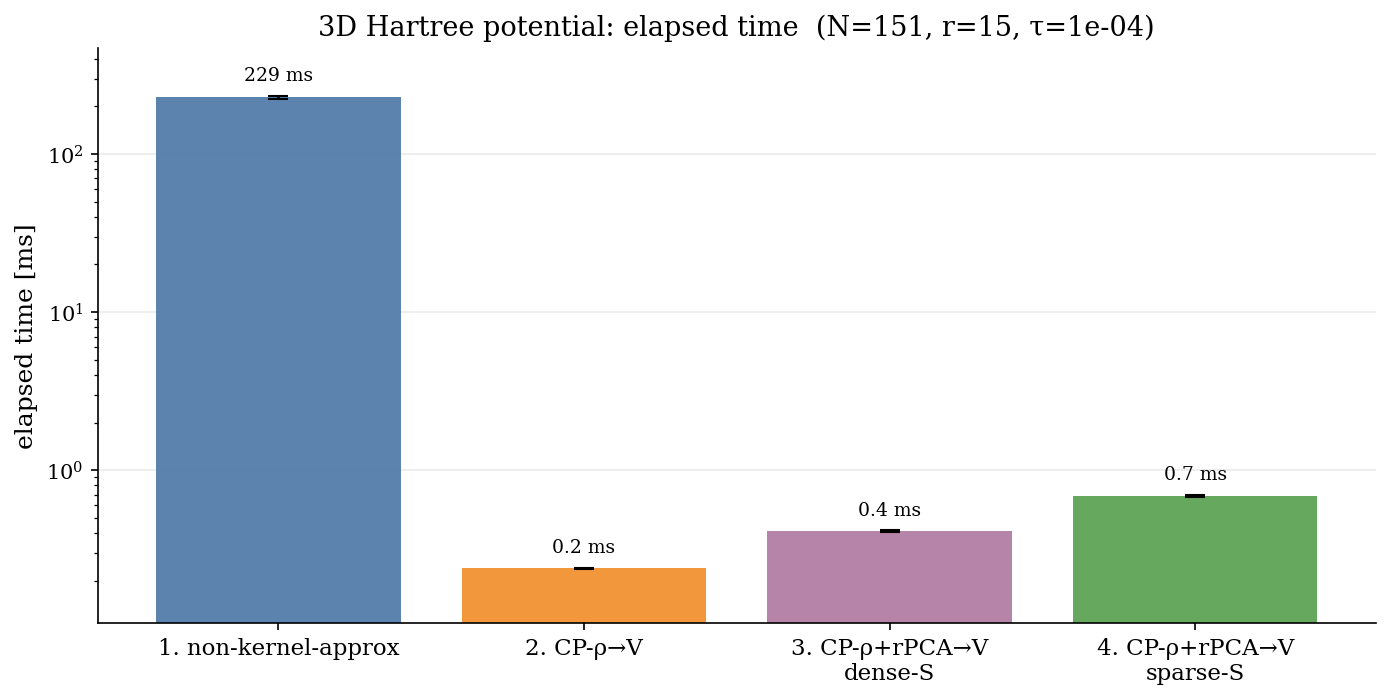

method                  mean [ms]  std [ms]  min [ms]
-------------------------------------------------------
1. non-kernel-approx        228.6       4.5     225.6
2. CP-ρ→V                     0.2       0.0       0.2
3. CP-ρ+rPCA→V
dense-S        0.4       0.0       0.4
4. CP-ρ+rPCA→V
sparse-S        0.7       0.0       0.7


In [39]:
# ---- タイミング結果の可視化 ----
keys = [key for key in DISPLAY_METHODS if key in timing_results]
means_ms = np.array([timing_results[key].mean() * 1e3 for key in keys])
stds_ms = np.array([timing_results[key].std() * 1e3 for key in keys])
labels = [METHOD_LABELS[key] for key in keys]

def _format_ms(value: float) -> str:
    return f"{value:.1f} ms" if value < 10 else f"{value:.0f} ms"

fig, ax = plt.subplots(figsize=(9.4, 4.8))
x = np.arange(len(keys))
bars = ax.bar(
    x,
    means_ms,
    yerr=stds_ms,
    capsize=5,
    color=["#4E79A7", "#F28E2B", "#B07AA1", "#59A14F", "#E15759", "#76B7B2"],
    alpha=0.92,
)
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=0, ha="center", fontsize=11)
ax.set_ylabel("elapsed time [ms]", fontsize=12)
ax.set_title(
    f"3D Hartree potential: elapsed time  "
    f"(N={timing_params.get('N')}, "
    f"r={timing_params.get('r_bench')}, "
    f"τ={timing_params.get('tau_bench'):.0e})",
    fontsize=13,
)
ax.grid(axis="y", which="major", alpha=0.25)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
for bar, mean_ms, std_ms in zip(bars, means_ms, stds_ms):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        (mean_ms + std_ms) * 1.18,
        _format_ms(mean_ms),
        ha="center",
        va="bottom",
        fontsize=9,
    )
ax.set_ylim(max(means_ms.min() * 0.45, 1e-3), (means_ms + stds_ms).max() * 2.0)
plt.tight_layout()
_fig_dir = PROJECT_ROOT / "results" / "figures"
_fig_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(_fig_dir / "timing_elapsed_slide.png", dpi=300, bbox_inches="tight")
fig.savefig(_fig_dir / "timing_elapsed_slide.pdf", bbox_inches="tight")
plt.show()

# ---- 数値表 ----
print(f"{'method':<22} {'mean [ms]':>10} {'std [ms]':>9} {'min [ms]':>9}")
print("-" * 55)
for key, mean_ms, std_ms in zip(keys, means_ms, stds_ms):
    min_ms = timing_results[key].min() * 1e3
    print(
        f"{METHOD_LABELS[key]:<22} "
        f"{mean_ms:>10.1f} {std_ms:>9.1f} {min_ms:>9.1f}"
    )


In [36]:
import torch
import os
from src.approximation.torch_kernels import (
    apply_dense_axis,
    apply_low_rank_axis,
    to_float64_tensor,
)

# ---- 計測用パラメータ ----
r_bench = 15 # SVD/RPCAのランク（1Dガウシアンあたり）
tau_bench = 1e-2

# ---- データの準備（PyTorch テンソルへの変換を同時に行う） ----
rpca_dense_data_pt = []
rpca_lowrank_only_data_pt = []
lowrank_data_pt = []
full_kernels_pt = []

lowrank_only_count = 0
dense_count = 0

for i, (alpha_k, w_k) in enumerate(zip(fit.alphas, fit.weights)):
    K_1d = K_1d_list[i]
    k_data = RPCA_1d_list[i]

    # SVD
    Ur = k_data['U_s'][:, :r_bench]
    sr = k_data['S_s'][:r_bench]
    Vtr = k_data['Vt_s'][:r_bench, :]

    # RPCA (L+S)
    UrL = k_data['U_L'][:, :r_bench]
    srL = k_data['S_L'][:r_bench]
    VtrL = k_data['Vt_L'][:r_bench, :]

    S_1d = k_data['S_1d']
    S_thr = np.where(np.abs(S_1d) > tau_bench, S_1d, 0.0)
    nnz = np.count_nonzero(S_thr)

    # 共通の LowRank データ (PyTorch化)
    Ur_pt = to_float64_tensor(Ur)
    sr_pt = to_float64_tensor(sr)
    Vtr_pt = to_float64_tensor(Vtr)
    lowrank_data_pt.append((w_k, Ur_pt, sr_pt, Vtr_pt))

    K_1d_pt = to_float64_tensor(K_1d)
    full_kernels_pt.append((w_k, K_1d_pt))

    UrL_pt = to_float64_tensor(UrL)
    srL_pt = to_float64_tensor(srL)
    VtrL_pt = to_float64_tensor(VtrL)

    if nnz == 0:
        rpca_lowrank_only_data_pt.append((w_k, UrL_pt, srL_pt, VtrL_pt))
        lowrank_only_count += 1
    else:
        S_thr_pt = to_float64_tensor(S_thr)
        rpca_dense_data_pt.append((w_k, UrL_pt, srL_pt, VtrL_pt, S_thr_pt))
        dense_count += 1

print(
    f"rpca path: dense={dense_count}, lowrank_only={lowrank_only_count} "
    "(backend = PyTorch)"
)

rpca path: dense=10, lowrank_only=1 (backend = PyTorch)


#### 論文用の出力

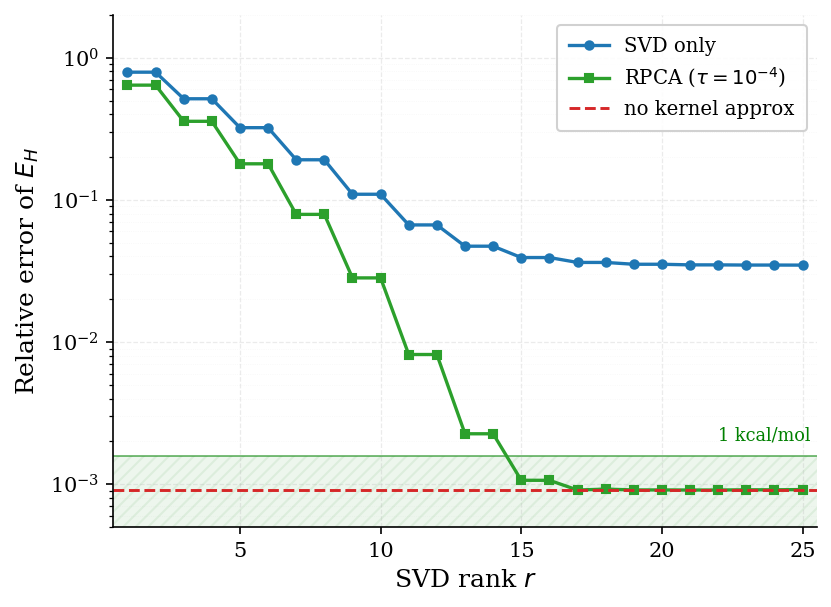

In [20]:
# ===== 論文用: SVD-only / RPCA(τ=1e-4) / exp-sum only  Hartree エネルギー誤差 =====
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from pathlib import Path
from src.utils.cache import rpca_label as make_rpca_label, exp_sum_label as make_exp_sum_label
from src.utils.grid import build_xyz
from src.potential.separable_density import (
    make_gaussian_density_terms,
    apply_exp_sum_to_separable_density,
)
from src.approximation.exp_sum.models import ExponentialSum
from src.potential.charge_potential import v_analytic_gaussian

_N, _L, _alpha = 151, 20, 1.0
_dx = _L / _N
_exp_sum_R = 11
_svd_ranks = list(range(1, 26))
_rank_label = f"r{min(_svd_ranks):02d}-{max(_svd_ranks):02d}"
_cell_int_const = 2.38

_PROJECT_ROOT = Path.cwd()
if not (_PROJECT_ROOT / "data").exists() and (_PROJECT_ROOT.parent / "data").exists():
    _PROJECT_ROOT = _PROJECT_ROOT.parent

_es_label = make_exp_sum_label(
    L=_L, ranks=list(range(1, 31)), nonneg=True,
    max_iter=200000, n_points=2000,
    r_min=1e-2, r_max=np.sqrt(3) * _L,
)
_es_dir = _PROJECT_ROOT / "data" / "npy" / "exp_sum" / _es_label
_fit = ExponentialSum(
    weights=np.load(_es_dir / f"R{_exp_sum_R:02d}_weights.npy"),
    alphas=np.load(_es_dir / f"R{_exp_sum_R:02d}_alphas.npy"),
)

_xyz = build_xyz(_N, _L)
_R_grid = np.sqrt(_xyz[0]**2 + _xyz[1]**2 + _xyz[2]**2)
_rho = np.exp(-_alpha * _R_grid**2)
_V_analytic = v_analytic_gaussian(_R_grid, _alpha)
_E_analytic = 0.5 * np.sum(_rho * _V_analytic) * _dx**3
_x_axis = _xyz[0, :, 0, 0]
_rho_terms = make_gaussian_density_terms(_x_axis, _alpha)
_diag_coeff = _cell_int_const / _dx - _fit.weights.sum()
_V_corr = apply_exp_sum_to_separable_density(
    fit=_fit, x_axis=_x_axis, density_terms=_rho_terms,
    dx=_dx, diag_coeff=_diag_coeff,
)
_E_corr = 0.5 * np.sum(_rho * _V_corr) * _dx**3
_ref_e = abs(_E_corr - _E_analytic) / abs(_E_analytic)

_rpca_lbl = make_rpca_label(
    N=_N, L=_L, exp_sum_R=_exp_sum_R,
    rpca_rank=_N // 4, rpca_max_iter=2000, rpca_tol=1e-6,
)
_sweep_dir = (
    _PROJECT_ROOT / "data" / "npy" / "rpca_error_sweep"
    / _es_label / _rpca_lbl / _rank_label
)
_svd_ranks_arr     = np.load(_sweep_dir / "svd_ranks.npy").astype(int)
_errors_e_svd      = np.load(_sweep_dir / "errors_e_svd_only.npy")
_errors_e_rpca_1e4 = np.load(_sweep_dir / "errors_e_rpca_thresh_1e-04.npy")

_chem_acc = 1.0 / 627.509474

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "legend.fontsize": 9.5,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

fig, ax = plt.subplots(figsize=(5.5, 4.0))

# 化学精度: 薄いハッチ帯 + ラベル直書き (凡例に入れない)
ax.axhspan(_chem_acc * 0.3, _chem_acc, alpha=0.07, color="green",
           hatch="////", linewidth=0.0, zorder=0)
ax.axhline(_chem_acc, lw=0.9, ls="-", color="green", alpha=0.55, zorder=1)
ax.text(25.3, _chem_acc * 1.2, "1 kcal/mol", color="green",
        fontsize=8.5, ha="right", va="bottom")

ax.semilogy(_svd_ranks_arr, _errors_e_svd, "o-",
            lw=1.6, ms=4, color="C0", label="SVD only")
ax.semilogy(_svd_ranks_arr, _errors_e_rpca_1e4, "s-",
            lw=1.6, ms=4, color="C2",
            label=r"RPCA ($\tau=10^{-4}$)")
ax.axhline(_ref_e, ls="--", lw=1.4, color="C3",
           label=rf"no kernel approx")

ax.set_xlabel(r"SVD rank $r$")
ax.set_ylabel(r"Relative error of $E_H$")
ax.set_xlim(0.5, 25.5)
ax.set_ylim(5e-4, 2.0)
ax.yaxis.set_major_locator(ticker.LogLocator(base=10, numticks=5))
ax.grid(True, which="major", alpha=0.25, ls="--", lw=0.6)
ax.grid(True, which="minor", alpha=0.10, ls=":", lw=0.4)
ax.legend(loc="upper right", framealpha=0.9, edgecolor="0.8",
          handlelength=2.0, borderpad=0.6)

plt.tight_layout(pad=0.5)
plt.show()


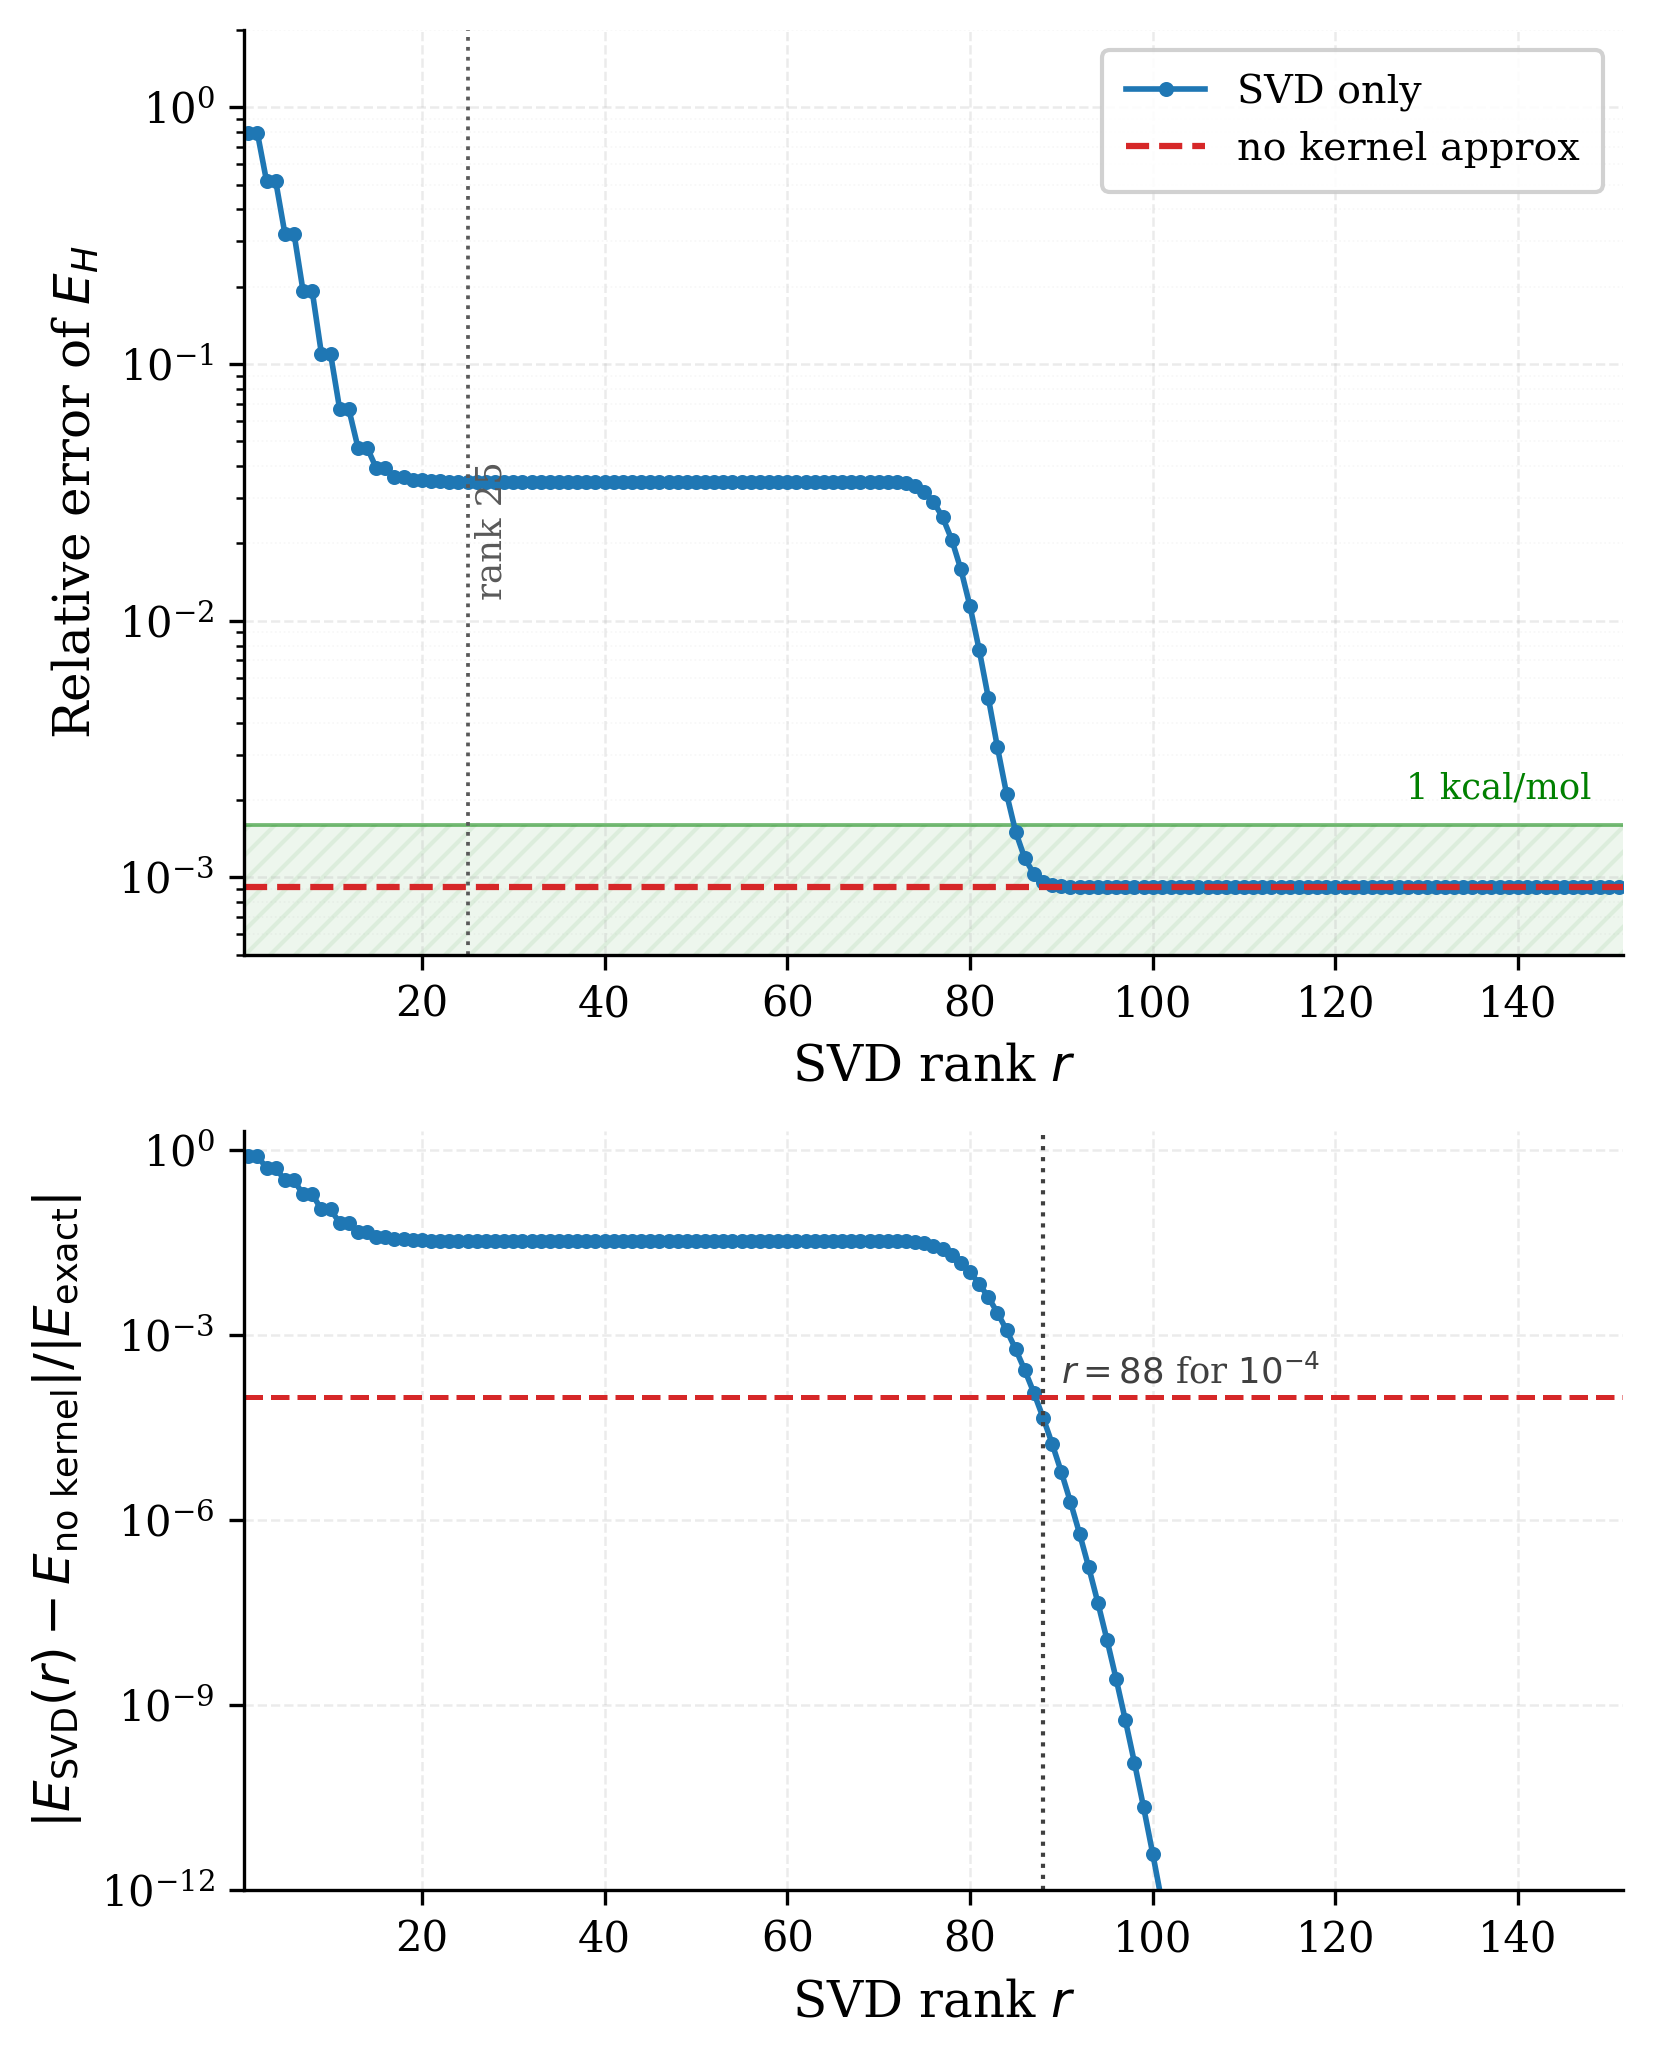

In [39]:
# ===== 論文用: SVD-only が no kernel approx に近づく様子 =====
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from pathlib import Path
from src.utils.cache import (
    load_rpca_1d_list,
    rpca_label as make_rpca_label,
    exp_sum_label as make_exp_sum_label,
)
from src.utils.grid import build_xyz
from src.potential.separable_density import (
    make_gaussian_density_terms,
    apply_exp_sum_to_separable_density,
)
from src.approximation.exp_sum.models import ExponentialSum
from src.potential.charge_potential import v_analytic_gaussian

_N, _L, _alpha = 151, 20, 1.0
_dx = _L / _N
_exp_sum_R = 11
_cell_int_const = 2.38
_svd_ranks_full = np.arange(1, _N + 1)

_PROJECT_ROOT = Path.cwd()
if not (_PROJECT_ROOT / "data").exists() and (_PROJECT_ROOT.parent / "data").exists():
    _PROJECT_ROOT = _PROJECT_ROOT.parent

_es_label = make_exp_sum_label(
    L=_L, ranks=list(range(1, 31)), nonneg=True,
    max_iter=200000, n_points=2000,
    r_min=1e-2, r_max=np.sqrt(3) * _L,
)
_es_dir = _PROJECT_ROOT / "data" / "npy" / "exp_sum" / _es_label
_fit = ExponentialSum(
    weights=np.load(_es_dir / f"R{_exp_sum_R:02d}_weights.npy"),
    alphas=np.load(_es_dir / f"R{_exp_sum_R:02d}_alphas.npy"),
)

_xyz = build_xyz(_N, _L)
_R_grid = np.sqrt(_xyz[0]**2 + _xyz[1]**2 + _xyz[2]**2)
_rho = np.exp(-_alpha * _R_grid**2)
_V_analytic = v_analytic_gaussian(_R_grid, _alpha)
_E_exact = 0.5 * np.sum(_rho * _V_analytic) * _dx**3
_x_axis = _xyz[0, :, 0, 0]
_rho_terms = make_gaussian_density_terms(_x_axis, _alpha)
_rho_x = _rho_terms[0].fx
_diag_coeff = _cell_int_const / _dx - _fit.weights.sum()

_V_no_kernel = apply_exp_sum_to_separable_density(
    fit=_fit, x_axis=_x_axis, density_terms=_rho_terms,
    dx=_dx, diag_coeff=_diag_coeff,
)
_E_no_kernel = 0.5 * np.sum(_rho * _V_no_kernel) * _dx**3
_err_e_no_kernel = abs(_E_no_kernel - _E_exact) / abs(_E_exact)

# 保存済みの通常 SVD 因子 U_s, S_s, Vt_s を読み込む。
# ディレクトリ名は rpca_kernels だが、ここでは RPCA 成分は使わない。
_svd_factor_label = make_rpca_label(
    N=_N, L=_L, exp_sum_R=_exp_sum_R,
    rpca_rank=_N // 4, rpca_max_iter=2000, rpca_tol=1e-6,
)
_svd_factor_dir = (
    _PROJECT_ROOT / "data" / "npy" / "rpca_kernels"
    / _es_label / _svd_factor_label
)
_svd_1d_list = load_rpca_1d_list(_svd_factor_dir, n_terms=_fit.rank)

_rho_self = float(np.dot(_rho_x, _rho_x))
_diag_energy = 0.5 * _dx**6 * float(_diag_coeff) * _rho_self**3
_E_svd = []
for rank in _svd_ranks_full:
    energy = _diag_energy
    for weight, k_data in zip(_fit.weights, _svd_1d_list):
        projected = k_data["Vt_s"][:rank, :] @ _rho_x
        kernel_rho = k_data["U_s"][:, :rank] @ (
            k_data["S_s"][:rank] * projected
        )
        energy += (
            0.5 * _dx**6 * float(weight)
            * float(np.dot(_rho_x, kernel_rho))**3
        )
    _E_svd.append(energy)
_E_svd = np.asarray(_E_svd)
_errors_e_svd = np.abs(_E_svd - _E_exact) / abs(_E_exact)
_gap_to_no_kernel = np.abs(_E_svd - _E_no_kernel) / abs(_E_exact)

_gap_tol = 1e-4
_reached = np.flatnonzero(_gap_to_no_kernel <= _gap_tol)
_rank_at_tol = int(_svd_ranks_full[_reached[0]]) if _reached.size else None

_chem_acc = 1.0 / 627.509474

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "legend.fontsize": 9.5,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

fig, (ax, ax_gap) = plt.subplots(
    2, 1, figsize=(5.5, 6.8),
    gridspec_kw={"height_ratios": [1.0, 0.82]},
)

ax.axhspan(_chem_acc * 0.3, _chem_acc, alpha=0.07, color="green",
           hatch="////", linewidth=0.0, zorder=0)
ax.axhline(_chem_acc, lw=0.9, ls="-", color="green", alpha=0.55, zorder=1)
ax.text(_N * 0.98, _chem_acc * 1.2, "1 kcal/mol", color="green",
        fontsize=8.5, ha="right", va="bottom")

ax.semilogy(_svd_ranks_full, _errors_e_svd, "o-",
            lw=1.35, ms=2.6, color="C0", label="SVD only")
ax.axhline(_err_e_no_kernel, ls="--", lw=1.5, color="C3",
           label="no kernel approx")
ax.axvline(25, ls=":", lw=0.9, color="0.35")
ax.text(25.8, 1.2e-2, "rank 25", fontsize=8.5, color="0.35",
        ha="left", va="bottom", rotation=90)

ax.set_xlabel(r"SVD rank $r$")
ax.set_ylabel(r"Relative error of $E_H$")
ax.set_xlim(0.5, _N + 0.5)
ax.set_ylim(5e-4, 2.0)
ax.yaxis.set_major_locator(ticker.LogLocator(base=10, numticks=5))
ax.grid(True, which="major", alpha=0.25, ls="--", lw=0.6)
ax.grid(True, which="minor", alpha=0.10, ls=":", lw=0.4)
ax.legend(loc="upper right", framealpha=0.9, edgecolor="0.8",
          handlelength=2.0, borderpad=0.6)

ax_gap.semilogy(_svd_ranks_full, _gap_to_no_kernel, "o-",
                lw=1.35, ms=2.6, color="C0")
ax_gap.axhline(_gap_tol, ls="--", lw=1.2, color="C3")
if _rank_at_tol is not None:
    ax_gap.axvline(_rank_at_tol, ls=":", lw=1.0, color="0.25")
    ax_gap.text(
        _rank_at_tol + 2,
        _gap_tol * 1.25,
        rf"$r={_rank_at_tol}$ for $10^{{-4}}$",
        fontsize=8.5,
        ha="left",
        va="bottom",
        color="0.25",
    )
ax_gap.set_xlabel(r"SVD rank $r$")
ax_gap.set_ylabel(r"$|E_{\rm SVD}(r)-E_{\rm no\ kernel}|/|E_{\rm exact}|$")
ax_gap.set_xlim(0.5, _N + 0.5)
ax_gap.set_ylim(1e-12, 2.0)
ax_gap.yaxis.set_major_locator(ticker.LogLocator(base=10, numticks=5))
ax_gap.grid(True, which="major", alpha=0.25, ls="--", lw=0.6)
ax_gap.grid(True, which="minor", alpha=0.10, ls=":", lw=0.4)

plt.tight_layout(pad=0.55, h_pad=0.95)

_fig_dir = _PROJECT_ROOT / "figures"
_fig_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(_fig_dir / "svd_only_no_kernel_approach_paper.pdf", bbox_inches="tight")
fig.savefig(_fig_dir / "svd_only_no_kernel_approach_paper.png", dpi=300, bbox_inches="tight")

plt.show()
